In [1]:
## packages for cloud data intake: 
import s3fs
import fsspec

## packages for analysis
import pandas as pd
import xarray as xr
%config InlineBackend.figure_format = 'retina'
import seaborn as sb
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy import feature as cf
import cmocean
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
!pip install colormaps   #always need to install packages
import colormaps as cmaps
from dask import delayed
import rioxarray as rxr
import glob
from scipy.stats import pearsonr

  Using cached colormaps-0.5.0-py3-none-any.whl.metadata (7.7 kB)


Using cached colormaps-0.5.0-py3-none-any.whl (688 kB)


### VALIDATION THAT MODELS CAPTURE RAINFALL PATTERN

* Check for the rainfall pattern associated with WACCM and UKESM historical and compare with CHIRPS (Monthly TS)
* Compute relative difference and RMSE for WACCM and UKESM comparing to CHIRPS

In [2]:
# Connect to AWS S3 storage and load WACCM historical Precipitation 
fs = s3fs.S3FileSystem(anon=True)

# load catalogue
df = pd.read_csv("https://cmip6-pds.s3.amazonaws.com/pangeo-cmip6.csv")

# subset the archive
df_subset = df.query(
    "activity_id=='CMIP'& source_id=='CESM2-WACCM' & \
    experiment_id=='historical' & table_id=='Amon' & \
    variable_id=='pr'")

# get the path to a specific zarr store
zstores = df_subset.zstore.values#[0]
zstores

array(['s3://cmip6-pds/CMIP6/CMIP/NCAR/CESM2-WACCM/historical/r3i1p1f1/Amon/pr/gn/v20190415/',
       's3://cmip6-pds/CMIP6/CMIP/NCAR/CESM2-WACCM/historical/r2i1p1f1/Amon/pr/gn/v20190415/',
       's3://cmip6-pds/CMIP6/CMIP/NCAR/CESM2-WACCM/historical/r1i1p1f1/Amon/pr/gn/v20190415/'],
      dtype=object)

In [3]:
lon_slice = slice(-25, 25)
lat_slice = slice(0,20)
time_slice = slice("1981","2014")

In [4]:
lon_name = 'lon'
lat_name = 'lat'

waccm_ens = []
for zstore in zstores:
    waccm_hist_pr = xr.open_dataset(
        zstore,
        engine="zarr",
        consolidated=True,
        chunks={},                        # or {} / None or 'auto' as you prefer
        storage_options={"anon": True}).assign_coords({lon_name: lambda ds: ((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name).sel({
        "time" : time_slice,
        lon_name : lon_slice, 
        lat_name : lat_slice}).load()* 24 * 60 * 60 * 31

    waccm_ens.append(waccm_hist_pr)

In [5]:
waccm_hist_pr_ = xr.concat(waccm_ens, dim='ensemble')

In [6]:
# Connect to AWS S3 storage and load UKESM historical Precipitation 
fs = s3fs.S3FileSystem(anon=True)

# load catalogue
df = pd.read_csv("https://cmip6-pds.s3.amazonaws.com/pangeo-cmip6.csv")

# subset the archive
df_subset = df.query(
    "activity_id=='CMIP'& source_id=='UKESM1-0-LL' & \
    experiment_id=='historical' & table_id=='Amon' & \
    variable_id=='pr'")

# get the path to a specific zarr store
zstores = df_subset.zstore.values#[0]
zstores

array(['s3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/Amon/pr/gn/v20190406/',
       's3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r3i1p1f2/Amon/pr/gn/v20190502/',
       's3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r8i1p1f2/Amon/pr/gn/v20190502/',
       's3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r2i1p1f2/Amon/pr/gn/v20190502/',
       's3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r4i1p1f2/Amon/pr/gn/v20190502/',
       's3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r5i1p1f3/Amon/pr/gn/v20190510/',
       's3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r9i1p1f2/Amon/pr/gn/v20190603/',
       's3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r7i1p1f3/Amon/pr/gn/v20190603/',
       's3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r6i1p1f3/Amon/pr/gn/v20190604/',
       's3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r17i1p1f2/Amon/pr/gn/v20191115/',
       's3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-L

In [7]:
lon_name = 'lon'
lat_name = 'lat'
ukesm_ens = []
for zstore in zstores:
    
    ukesm_hist_pr = xr.open_dataset(
        zstore,
        engine="zarr",
        consolidated=True,
        chunks={},                        # or {} / None or 'auto' as you prefer
        storage_options={"anon": True}).assign_coords({lon_name: lambda ds: ((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name).sel({
        "time" : time_slice,
        lon_name : lon_slice, 
        lat_name : lat_slice}).load() * 24 * 60 * 60 * 31
    ukesm_ens.append(ukesm_hist_pr)

In [8]:
ukesm_hist_pr_ = xr.concat(ukesm_ens,dim='ensemble')

In [9]:
chirps_hist_pr = delayed(xr.open_mfdataset)('CHIRPS_monthly/chirps_yearly_nc/*.nc').where(
    lambda ds: ds['pr']>=0)['pr'].sel(time=slice("1981","2014")).load().compute()

In [10]:
# Replace these with your variables
ukesm_monthly = ukesm_hist_pr_.groupby('time.month').mean(['ensemble','time']).mean(['lat','lon'])['pr']  # DataArray with dims ("month", ...)
waccm_monthly = waccm_hist_pr_.groupby('time.month').mean(['ensemble','time']).mean(['lat','lon'])['pr'] 
chirps_monthly = chirps_hist_pr.groupby('time.month').mean('time').mean(['lat','lon']) 

In [11]:
import seaborn as sb

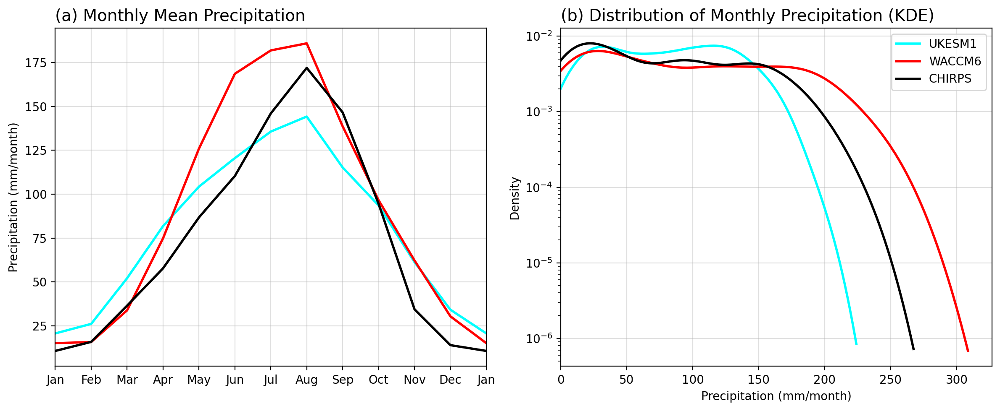

In [13]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

# ------------------------------------------------------------
# Spatial means
# ------------------------------------------------------------
def spatial_mean_if_needed(da):
    if {"lat", "lon"} <= set(da.dims):
        return da.mean(["lat", "lon"])
    return da

uk = spatial_mean_if_needed(ukesm_monthly)
wa = spatial_mean_if_needed(waccm_monthly)
ch = spatial_mean_if_needed(chirps_monthly)

# ------------------------------------------------------------
# Wrap seasonal cycle: append January after December
# ------------------------------------------------------------
months = np.arange(1, 14)

uk_wrap = np.r_[uk.values, uk.sel(month=1).values]
wa_wrap = np.r_[wa.values, wa.sel(month=1).values]
ch_wrap = np.r_[ch.values, ch.sel(month=1).values]

# ------------------------------------------------------------
# Create figure
# ------------------------------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# ---------------------- Panel 1: Line Plot -------------------
axs[0].plot(months, uk_wrap, label="UKESM1", linewidth=2, color="cyan")
axs[0].plot(months, wa_wrap, label="WACCM6", linewidth=2, color="red")
axs[0].plot(months, ch_wrap, label="CHIRPS", linewidth=2, color="black")

axs[0].set_xticks(range(1, 14))
axs[0].set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec","Jan"])
axs[0].set_xlim(1, 13)
axs[0].set_ylabel("Precipitation (mm/month)")
axs[0].set_title("(a) Monthly Mean Precipitation", loc="left", fontsize=14)
axs[0].grid(True, alpha=0.4)

# ------------------------------------------------------------
# Original time series for distribution
# ------------------------------------------------------------
uk = ukesm_hist_pr["pr"].mean(["lon", "lat"])
wa = waccm_hist_pr["pr"].mean(["lon", "lat"])
ch = chirps_hist_pr.mean(["lon", "lat"])

# ---------------------- Panel 2: KDE Plot --------------------
sb.kdeplot(uk, ax=axs[1], label="UKESM1", linewidth=2, color="cyan")
sb.kdeplot(wa, ax=axs[1], label="WACCM6", linewidth=2, color="red")
sb.kdeplot(ch, ax=axs[1], label="CHIRPS", linewidth=2, color="black")

axs[1].set_xlim(0, None)
axs[1].set_yscale("log")
axs[1].set_xlabel("Precipitation (mm/month)")
axs[1].set_title("(b) Distribution of Monthly Precipitation (KDE)", loc="left", fontsize=14)
axs[1].grid(True, alpha=0.4)
axs[1].legend()

plt.tight_layout()
plt.savefig("Images/validation_v2.png", dpi=300, bbox_inches="tight")
plt.show()

For the plot above, we use UKESM 1 because that is what is available, however, the results from https://gmd.copernicus.org/articles/16/1569/2023/ shows that the response in precipitation for both UKESM1-1 and UKESM1-1 are identical, with extremely small differences.

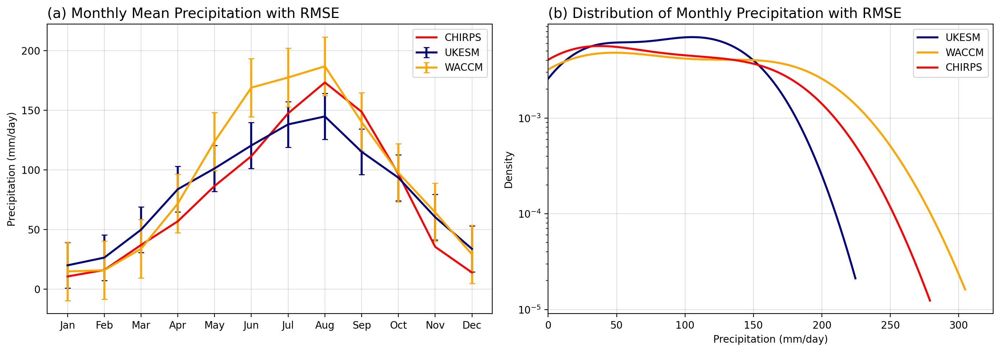

In [107]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

# -------------------------
# Function to compute RMSE
# -------------------------
def rmse(pred, obs):
    return np.sqrt(np.mean((pred - obs)**2, axis=0))

# -------------------------
# Make spatial means if needed
# -------------------------
def spatial_mean_if_needed(da):
    if {"lat", "lon"} <= set(da.dims):
        return da.mean(["lat", "lon"])
    return da

uk = spatial_mean_if_needed(ukesm_monthly)
wa = spatial_mean_if_needed(waccm_monthly)
ch = spatial_mean_if_needed(chirps_monthly)

# Compute RMSE relative to CHIRPS
uk_rmse = rmse(uk, ch)
wa_rmse = rmse(wa, ch)

# ----------------------------
# Figure with 2 panels
# ----------------------------
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------- Panel 1: Line Plot -------------------
months = np.arange(1, 13)

axs[0].errorbar(months, uk, yerr=uk_rmse, label="UKESM", linewidth=2, color='cyan', capsize=3)
axs[0].errorbar(months, wa, yerr=wa_rmse, label="WACCM", linewidth=2, color='red', capsize=3)
axs[0].plot(months, ch, label="CHIRPS", linewidth=2, color='black')  # observations, no error

axs[0].set_xticks(months)
axs[0].set_xticklabels(
    ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
)
axs[0].set_ylabel("Precipitation (mm/day)")
axs[0].set_title("(a) Monthly Mean Precipitation with RMSE", loc='left', fontsize=14)
axs[0].grid(True, alpha=0.4)
axs[0].legend()

# ---------------------- Panel 2: KDE Plot with RMSE shading --------------------
# For KDE shading, approximate RMSE by +/- std around KDE mean
uk_mean, wa_mean, ch_mean = uk.mean(), wa.mean(), ch.mean()
uk_std, wa_std = uk_rmse.mean(), wa_rmse.mean()  # average RMSE as approximate std

sb.kdeplot(uk, ax=axs[1], label="UKESM", linewidth=2, color='cyan')
# axs[1].fill_betweenx(
#     y=np.linspace(0, 1.1*uk.max(), 100),
#     x1=uk_mean-uk_std,
#     x2=uk_mean+uk_std,
#     color='navy', alpha=0.2
# )

sb.kdeplot(wa, ax=axs[1], label="WACCM", linewidth=2, color='red')
# axs[1].fill_betweenx(
#     y=np.linspace(0, 1.1*wa.max(), 100),
#     x1=wa_mean-wa_std,
#     x2=wa_mean+wa_std,
#     color='orange', alpha=0.2
# )

sb.kdeplot(ch, ax=axs[1], label="CHIRPS", linewidth=2, color='black')

axs[1].set_xlim(0, None)
axs[1].set_yscale('log')
axs[1].set_xlabel("Precipitation (mm/day)")
axs[1].set_title("(b) Distribution of Monthly Precipitation with RMSE", loc='left', fontsize=14)
axs[1].grid(True, alpha=0.4)
axs[1].legend()

plt.tight_layout()
plt.savefig('Images/validation1_rmse.png', dpi=300)
plt.show()


In [45]:
convert = lambda x: chr(ord('`')+(x+1)) if x<26 else chr(ord('`')+((x)//25))+chr(ord('`')+(x+1)%26)

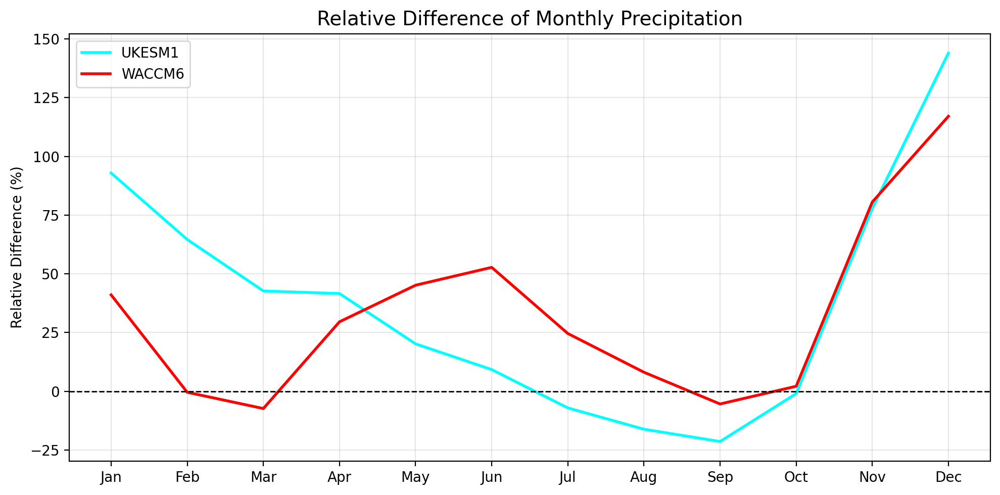

In [46]:

# ------------------------------------------------------------
# Compute spatial mean if needed
# ------------------------------------------------------------
def spatial_mean_if_needed(da):
    if {"lat", "lon"} <= set(da.dims):
        return da.mean(["lat", "lon"])
    return da

uk = spatial_mean_if_needed(ukesm_monthly)
wa = spatial_mean_if_needed(waccm_monthly)
ch = spatial_mean_if_needed(chirps_monthly)

# ------------------------------------------------------------
# Compute relative differences (%)
# ------------------------------------------------------------
uk_rel_diff = 100 * (uk - ch) / ch
wa_rel_diff = 100 * (wa - ch) / ch

# ------------------------------------------------------------
# Plot relative differences
# ------------------------------------------------------------
months = np.arange(1, 13)
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(months, uk_rel_diff, label='UKESM1', color='cyan', linewidth=2)
ax.plot(months, wa_rel_diff, label='WACCM6', color='red', linewidth=2)
ax.axhline(0, color='black', linestyle='--', linewidth=1)

ax.set_xticks(months)
ax.set_xticklabels(month_names)
ax.set_ylabel('Relative Difference (%)')
ax.set_title('Relative Difference of Monthly Precipitation', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig('Images/relative_diff.png',dpi=250)
plt.show()


### Regional Changes in Precip per Year

In [18]:
regions = {
    "Guinea Coast": {"lon": (-20, 10), "lat": (4, 8)},
    "Savannah":     {"lon": (-20, 10), "lat": (8, 12)},
    "Sahel":        {"lon": (-20, 10), "lat": (12, 18)},
}

In [42]:
def regional_yearly_mean(ds, var, region, ensemble_dim=None):
    da = ds[var].sel(
        lon=slice(region["lon"][0], region["lon"][1]),
        lat=slice(region["lat"][0], region["lat"][1])
    )
    # print(da)
    
    # average spatially
    da = da.reduce(np.nanmean, dim=['lat','lon'])
    
    # handle ensemble if present
    if ensemble_dim is not None and ensemble_dim in da.dims:
        da = da.reduce(np.nanmean, dim = ensemble_dim)
    
    # yearly mean
    da = da.groupby('time.year').mean('time')
    
    return da

In [38]:
chirps_hist_pr.sel(
        lon=slice(reg["lon"][0], reg["lon"][1]),
        lat=slice(reg["lat"][1], reg["lat"][0])
    )

<xarray.DataArray 'pr' (time: 408, lat: 120, lon: 600)> Size: 118MB
array([[[          nan,           nan,           nan, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [          nan,           nan,           nan, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [          nan,           nan,           nan, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        ...,
        [          nan,           nan,           nan, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [          nan,           nan,           nan, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [          nan,           nan,           nan, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00]],

       [[          nan,           nan,           nan, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [          nan,           nan,           nan, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [          nan,           nan,           nan, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
...
        [          nan,           nan,           nan, ...,
         3.3456057e-02, 6.5809205e-02, 6.9458112e-02],
        [          nan,           nan,           nan, ...,
         8.8756800e-02, 1.1837289e-01, 1.7267445e-01],
        [          nan,           nan,           nan, ...,
         7.8184351e-02, 1.6099308e-01, 2.1574725e-01]],

       [[          nan,           nan,           nan, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [          nan,           nan,           nan, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [          nan,           nan,           nan, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        ...,
        [          nan,           nan,           nan, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [          nan,           nan,           nan, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00],
        [          nan,           nan,           nan, ...,
         0.0000000e+00, 0.0000000e+00, 0.0000000e+00]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 3kB 1981-01-01 1981-02-01 ... 2014-12-01
  * lat      (lat) float64 960B 17.97 17.92 17.87 17.82 ... 12.12 12.07 12.02
  * lon      (lon) float64 5kB -19.97 -19.92 -19.87 -19.82 ... 9.875 9.925 9.975
Attributes:
    TIFFTAG_DOCUMENTNAME:      /home/CHIRPS/v3.0/monthly/africa/chirps-v3.0.1...
    TIFFTAG_IMAGEDESCRIPTION:  IDL TIFF file
    TIFFTAG_SOFTWARE:          IDL 8.9.0, L3Harris Geospatial Solutions, Inc.
    TIFFTAG_DATETIME:          2024:11:27 16:57:13
    TIFFTAG_XRESOLUTION:       100
    TIFFTAG_YRESOLUTION:       100
    TIFFTAG_RESOLUTIONUNIT:    2 (pixels/inch)
    AREA_OR_POINT:             Area

In [39]:
results = {}
results_sai = {}
for name, reg in regions.items():
    
    ukesm = regional_yearly_mean(ukesm_hist_pr_, 'pr', reg, ensemble_dim='ensemble')
    waccm = regional_yearly_mean(waccm_hist_pr_, 'pr', reg, ensemble_dim='ensemble')
    
    chirps = chirps_hist_pr.sel(
        lon=slice(reg["lon"][0], reg["lon"][1]),
        lat=slice(reg["lat"][1], reg["lat"][0])
    ).reduce(np.nanmean, dim=['lat','lon']).groupby('time.year').mean('time')
    
    results[name] = {
        "UKESM": ukesm,
        "WACCM": waccm,
        "CHIRPS": chirps
    }

<xarray.DataArray 'pr' (ensemble: 19, time: 408, lat: 3, lon: 16)> Size: 1MB
array([[[[7.40397797e+01, 8.27060852e+01, 1.22059296e+02, ...,
          1.84356940e+00, 7.32049084e+00, 8.02360630e+00],
         [2.94602070e+01, 1.72869282e+01, 1.64561157e+01, ...,
          5.98598003e+00, 7.86000347e+00, 2.89281487e+00],
         [9.88431263e+00, 2.08590126e+00, 5.81226921e+00, ...,
          2.86849546e+00, 2.31622458e+00, 1.52230889e-01]],

        [[1.02808914e+02, 1.10427002e+02, 1.05185699e+02, ...,
          2.00616646e+01, 5.24713936e+01, 6.30745506e+01],
         [1.00926828e+01, 4.70172882e+01, 8.84928818e+01, ...,
          1.45686235e+01, 5.87451553e+01, 1.99016056e+01],
         [3.39495599e-01, 3.24983865e-01, 2.03935122e+00, ...,
          4.23030357e+01, 3.08115902e+01, 7.61485147e+00]],

        [[2.69463718e-01, 2.96122938e-01, 1.49857223e+00, ...,
          5.38505211e+01, 1.53446335e+02, 1.38800369e+02],
         [1.16680406e-01, 1.08372465e-01, 1.23512045e-01, ...,
  

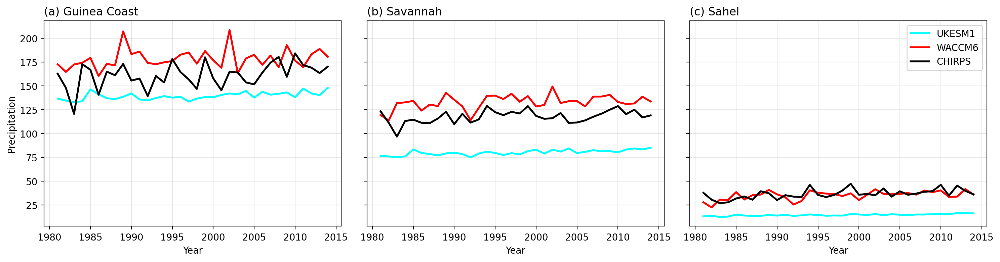

In [51]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,4), sharey=True)

for (ix,ax), (region, data) in zip(enumerate(axes), results.items()):
    
    ax.plot(data["UKESM"].year, data["UKESM"], label='UKESM1', linewidth=2,color='cyan')
    ax.plot(data["WACCM"].year, data["WACCM"], label='WACCM6', linewidth=2, color='red')
    ax.plot(data["CHIRPS"].year, data["CHIRPS"], label='CHIRPS', linewidth=2, color='black')
    
    ax.set_title(f'({convert(ix)}) {region}', loc='left')
    ax.set_xlabel("Year")
    ax.grid(alpha=0.3)

axes[0].set_ylabel("Precipitation")

axes[-1].legend(loc='upper right')

plt.tight_layout()
plt.savefig('Images/precip_change_per_year_historical.png',dpi=250, bbox_inches="tight")
plt.show()

In [ ]:
lons,lats = chirps_hist_pr.lon.values, chirps_hist_pr.lat.values
times = chirps_hist_pr.time.values


ukesm_hist_pr_interp = ukesm_hist_pr.interp({'lon':lons,'lat':lats})['pr']
waccm_hist_pr_interp = waccm_hist_pr.interp({'lon':lons,'lat':lats})['pr']

waccm_hist_pr_interp['time'] = times
ukesm_hist_pr_interp['time'] = times

ds_use = [(ukesm_hist_pr_interp-chirps_hist_pr)/chirps_hist_pr,
          (waccm_hist_pr_interp-chirps_hist_pr)/chirps_hist_pr]

fig,axes = plt.subplots(ncols=2, figsize=(10,5), subplot_kw={'projection':ccrs.PlateCarree()})

for axs,dsu in zip(axes.flat,ds_use):

    _use_ds = dsu.sel(time=dsu.time.dt.month.isin([6,7,8])).mean('time') *100
    dsu.plot(ax=axs
            )

In [75]:
rmse_map = xr.apply_ufunc(
    lambda x, y: mean_squared_error(x, y, squared=False),
    chirps_da, waccm_da,
    vectorize=True
)

np.float64(95.7054160812967)

In [79]:
d1

<xarray.DataArray 'pr' (time: 102, lat: 21, lon: 41)> Size: 703kB
array([[[           nan,            nan,            nan, ...,
         1.91241390e+02, 1.32738059e+02,            nan],
        [           nan,            nan,            nan, ...,
         2.46217234e+02, 1.95801661e+02,            nan],
        [           nan,            nan,            nan, ...,
         2.04196763e+02, 2.36332317e+02,            nan],
        ...,
        [           nan,            nan,            nan, ...,
         8.96484895e+00, 2.37899860e-01,            nan],
        [           nan,            nan,            nan, ...,
         1.33891123e-01, 4.98648682e-03,            nan],
        [           nan,            nan,            nan, ...,
         0.00000000e+00, 0.00000000e+00,            nan]],

       [[           nan,            nan,            nan, ...,
         2.29688190e+02, 2.02666832e+02,            nan],
        [           nan,            nan,            nan, ...,
         2.50078428e+02, 1.97839604e+02,            nan],
        [           nan,            nan,            nan, ...,
         2.40051745e+02, 2.22722788e+02,            nan],
...
        [           nan,            nan,            nan, ...,
         6.09052011e+01, 5.33359493e+01,            nan],
        [           nan,            nan,            nan, ...,
         5.80639757e+00, 2.87501420e+01,            nan],
        [           nan,            nan,            nan, ...,
         1.49955952e+00, 7.92431032e+00,            nan]],

       [[           nan,            nan,            nan, ...,
         1.59472231e+02, 1.12839823e+02,            nan],
        [           nan,            nan,            nan, ...,
         1.48702535e+02, 1.58046116e+02,            nan],
        [           nan,            nan,            nan, ...,
         1.72636709e+02, 1.22853001e+02,            nan],
        ...,
        [           nan,            nan,            nan, ...,
         1.10006803e+02, 5.25876292e+01,            nan],
        [           nan,            nan,            nan, ...,
         1.28941363e+01, 2.72813226e+01,            nan],
        [           nan,            nan,            nan, ...,
         2.53294589e+00, 8.28718732e+00,            nan]]])
Coordinates:
  * time     (time) datetime64[ns] 816B 1981-06-01 1981-07-01 ... 2014-08-01
  * lon      (lon) float64 328B -25.0 -23.75 -22.5 -21.25 ... 22.5 23.75 25.0
  * lat      (lat) float64 168B 0.4712 1.414 2.356 3.298 ... 17.43 18.38 19.32
Attributes:
    TIFFTAG_DOCUMENTNAME:      /home/CHIRPS/v3.0/monthly/africa/chirps-v3.0.1...
    TIFFTAG_IMAGEDESCRIPTION:  IDL TIFF file
    TIFFTAG_SOFTWARE:          IDL 8.9.0, L3Harris Geospatial Solutions, Inc.
    TIFFTAG_DATETIME:          2024:11:27 16:57:13
    TIFFTAG_XRESOLUTION:       100
    TIFFTAG_YRESOLUTION:       100
    TIFFTAG_RESOLUTIONUNIT:    2 (pixels/inch)
    AREA_OR_POINT:             Area

In [78]:
d2

<xarray.DataArray 'pr' (time: 102, lat: 21, lon: 41)> Size: 351kB
dask.array<getitem, shape=(102, 21, 41), dtype=float32, chunksize=(102, 21, 41), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 168B 0.4712 1.414 2.356 3.298 ... 17.43 18.38 19.32
  * time     (time) object 816B 1981-06-15 00:00:00 ... 2014-08-15 12:00:00
  * lon      (lon) float64 328B -25.0 -23.75 -22.5 -21.25 ... 22.5 23.75 25.0

### Precip Analyses

1. Divide data into 2 parts (25 years each)
2. Subtract CHIRPS from the data and plot the residuals (compute statistical significance)

The idea here is to check how the monsoon systems deviates from observations under SAI in the 2 models assessed 

Which months did we observe the highest deviations for near future and far future?

In [2]:
## Load this helper function

def open_s3_xarray_ukesm(bucket, group, scenario, variable_name, partial_filename, anon=False):
    fs = s3fs.S3FileSystem(anon=anon)
    keys = fs.glob(f"{bucket}/{group}/{scenario}/{variable_name}_{partial_filename}*.nc")
    urls = [f"simplecache::s3://{k}" for k in keys][:2]
    print(f"{bucket}/{group}/{scenario}/{variable_name}_{partial_filename}*.nc")
    ds = xr.open_mfdataset(
        urls,
        engine="h5netcdf",
        combine="by_coords",
        parallel=True,
        backend_kwargs={
            "storage_options": {
                "s3": {"anon": anon},
                "simplecache": {"cache_storage": "/tmp/s3cache"},
            }
        },
    )
    lon_names = ['longitude', 'lon']
    lon_name = [ln for ln in lon_names if ln in ds][0]
    
    lat_names = ['latitude', 'lat']
    lat_name = [lt for lt in lat_names if lt in ds][0]
    print(lat_name)
    
    # ds = ds.assign_coords({lon_name:((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    ds = ds.assign_coords({lon_name: ((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    if lon_name != "lon":
        ds = ds.rename({lon_name: "lon", lat_name:"lat"})
    
    return ds


## Load this helper function

def open_s3_xarray_waccm(bucket, group, scenario, variable_name, partial_filename, anon=False):
    fs = s3fs.S3FileSystem(anon=anon)
    keys = fs.glob(f"{bucket}/{group}/{scenario}{variable_name}{partial_filename}*.nc")
    urls = [f"simplecache::s3://{k}" for k in keys]
    print(urls)
    print(f"{bucket}/{group}/{scenario}{variable_name}{partial_filename}*.nc")
    ds = xr.open_mfdataset(
        urls,
        engine="h5netcdf",
        combine="by_coords",
        parallel=True,
        backend_kwargs={
            "storage_options": {
                "s3": {"anon": anon},
                "simplecache": {"cache_storage": "/tmp/s3cache"},
            }
        },
    )
    lon_names = ['longitude', 'lon']
    lon_name = [ln for ln in lon_names if ln in ds][0]
    
    lat_names = ['latitude', 'lat']
    lat_name = [lt for lt in lat_names if lt in ds][0]
    print(lat_name)
    
    # ds = ds.assign_coords({lon_name:((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    ds = ds.assign_coords({lon_name: ((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    if lon_name != "lon":
        ds = ds.rename({lon_name: "lon", lat_name:"lat"})
    
    return ds


def cart_plot(axes,ix, ncols=3,nrows=3, rlon=-150,llon=-60,tlat=42,blat=15):
    axes.add_feature(cf.BORDERS,linewidth=0.2) #add features (boarders )
    axes.add_feature(cf.COASTLINE,linewidth=1,color='gray') #coastlines 
    gl=axes.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.01, linestyle='--') #create the map type with grids 
    axes.set_extent([llon,rlon,blat,tlat]) #set the extent of the map
    if ix%ncols ==0:
        
        gl.top_labels = False; gl.left_labels = True #set which axis labels should show 
        gl.right_labels=False; gl.xlines = False; gl.bottom_labels=False

    elif ix>=(ncols*nrows)-ncols:
        gl.top_labels = False; gl.left_labels = False #set which axis labels should show 
        gl.right_labels=False; gl.xlines = False; gl.bottom_labels=True

    else:
        gl.top_labels = False; gl.left_labels = False #set which axis labels should show 
        gl.right_labels=False; gl.xlines = False; gl.bottom_labels=False
    if ix == (ncols*nrows)-ncols:
        gl.top_labels = False; gl.left_labels = True #set which axis labels should show 
        gl.right_labels=False; gl.xlines = False; gl.bottom_labels=True
    axes.xformatter = LONGITUDE_FORMATTER;  axes.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'color':'black','size':12} #change font style for x-axis 
    gl.ylabel_style = {'color':'black','size':12}#change font style for y-axis  

convert = lambda x: chr(ord('`')+(x+1)) if x<26 else chr(ord('`')+((x)//25))+chr(ord('`')+(x+1)%26)

In [3]:
sim_time = slice("2035","2085")
_lon_slice, _lat_slice = slice(-25,30), slice(0,35)

In [4]:
ukesm_e1 = open_s3_xarray_ukesm(
    bucket="reflective-persistent-prod-large",
    group="UKESM1-1",
    scenario="G6-1p5K-HiLLA/r12i1p1f2/apm/Amon/pr",
    variable_name="pr",
    partial_filename="Amon_UKESM1-1-LL_g6-1p5-hilla_r12i1p1f2_gn",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)

ukesm_e2 = open_s3_xarray_ukesm(
    bucket="reflective-persistent-prod-large",
    group="UKESM1-1",
    scenario="G6-1p5K-HiLLA/r2i1p1f2/apm/Amon/pr",
    variable_name="pr",
    partial_filename="Amon_UKESM1-1-LL_g6-1p5-hilla_r2i1p1f2_gn",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)

ukesm_e3 = open_s3_xarray_ukesm(
    bucket="reflective-persistent-prod-large",
    group="UKESM1-1",
    scenario="G6-1p5K-HiLLA/r3i1p1f2/apm/Amon/pr",
    variable_name="pr",
    partial_filename="Amon_UKESM1-1-LL_g6-1p5-hilla_r3i1p1f2_gn",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)

reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r12i1p1f2/apm/Amon/pr/pr_Amon_UKESM1-1-LL_g6-1p5-hilla_r12i1p1f2_gn*.nc
lat
reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r2i1p1f2/apm/Amon/pr/pr_Amon_UKESM1-1-LL_g6-1p5-hilla_r2i1p1f2_gn*.nc
lat
reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r3i1p1f2/apm/Amon/pr/pr_Amon_UKESM1-1-LL_g6-1p5-hilla_r3i1p1f2_gn*.nc
lat


In [5]:
## Compute ensemble avg for ensemble members
ukesm_agv = (ukesm_e1['pr']+ukesm_e2['pr']+ukesm_e2['pr'])/3

In [6]:
ukesm_agv = ukesm_agv.to_dataset(name='pr')

In [7]:
sim_time = slice("2035","2085")
_lon_slice, _lat_slice = slice(-25,30), slice(0,35)

waccm_e1 = open_s3_xarray_waccm(
    bucket="reflective-persistent-prod-large",
    group="CESM2-WACCM",
    scenario="G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.",
    variable_name="PRECT",
    partial_filename="",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)[['PRECT']]


waccm_e2 = open_s3_xarray_waccm(
    bucket="reflective-persistent-prod-large",
    group="CESM2-WACCM",
    scenario="G6-1.5k-HiLLA/r2/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.002.cam.h0.",
    variable_name="PRECT",
    partial_filename="",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)[['PRECT']]

waccm_e3 = open_s3_xarray_waccm(
    bucket="reflective-persistent-prod-large",
    group="CESM2-WACCM",
    scenario="G6-1.5k-HiLLA/r3/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.003.cam.h0.",
    variable_name="PRECT",
    partial_filename="",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)[['PRECT']]

# ukesm_e1 = open_s3_xarray(
#     bucket="reflective-persistent-prod-large",
#     group="UKESM1-1",
#     scenario="G6-1p5K-HiLLA/r2i1p1f2/apm/Amon/pr",
#     variable_name="pr",
#     partial_filename="Amon_UKESM1-1-LL_g6-1p5-hilla_r2i1p1f2_gn",
# ).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)

['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.PRECT.203501-203912.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.PRECT.204001-208412.nc']
reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.PRECT*.nc
lat
['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r2/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.002.cam.h0.PRECT.203501-208412.nc']
reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r2/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.002.cam.h0.PRECT*.nc
lat
['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r3/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.003.cam.h0.PRECT.203501-208412.nc']
reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r3/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5

In [8]:
waccm_agv = (waccm_e1['PRECT']+waccm_e2['PRECT']+waccm_e3['PRECT'])/3

In [9]:
waccm_agv=waccm_agv.to_dataset(name='pr')

In [10]:

sel_months = [6,7,8,9]  #JJAS
months = ukesm_agv['time'].dt.month
ukesm_wam = ukesm_agv.isel(time=months.isin(sel_months)) * 24 * 60 * 60* 31
lons,lats = ukesm_wam.lon.values, ukesm_wam.lat.values
times = [np.datetime64(t) for t in ukesm_wam.time.values]
ukesm_wam['time'] = times


months = waccm_agv['time'].dt.month
waccm_wam = waccm_agv.isel(time=months.isin(sel_months)) * 24 * 60 * 60* 31 *1000
waccm_wam['time'] = times
waccm_wam = waccm_wam.interp({'lon':lons,'lat':lats})




/tmp/ipykernel_148/4236652959.py:6: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ukesm_wam['time'] = times
/tmp/ipykernel_148/4236652959.py:6: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead o

In [11]:
chirps_hist_pr = xr.open_mfdataset(
    "CHIRPS_monthly/chirps_yearly_nc2/*.nc",
    preprocess=lambda ds: ds.sel(time=ds.time.dt.month.isin(sel_months))).sel(time=slice("2000","2024")).where(lambda da: da >= 0)

chirps_wam = chirps_hist_pr.interp({'lon':lons,'lat':lats}).load()


In [12]:
years = np.unique(ukesm_wam.time.dt.year)

In [13]:
from scipy.stats import ttest_ind

In [17]:
near_fut = years[:25]
far_fut = years[25:]

dsnames = ['ukesm_wam','waccm_wam']
yr_sep = {'Near_Future': near_fut, 'Far_Future':far_fut}
for dsn in dsnames:
    _use_ds = eval(dsn)
    for yx,yr in enumerate(yr_sep.keys()):
        chirps = chirps_wam['pr']
        model = _use_ds.sel(time=_use_ds.time.dt.year.isin(yr_sep[yr]))['pr'].load()
        chirps['time']= model.time
        res = model - chirps
        locals()[f'{yr}_{dsn}'] = res.load()

        # Significance test
        tstat, pval = xr.apply_ufunc(
            ttest_ind,
            model,
            chirps,
            input_core_dims=[["time"], ["time"]],
            output_core_dims=[[], []],
            vectorize=True,
            dask="parallelized",
            output_dtypes=[float, float],
        )

        sig = pval < 0.05

        locals()[f'sig_{yr}_{dsn}'] = sig

/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


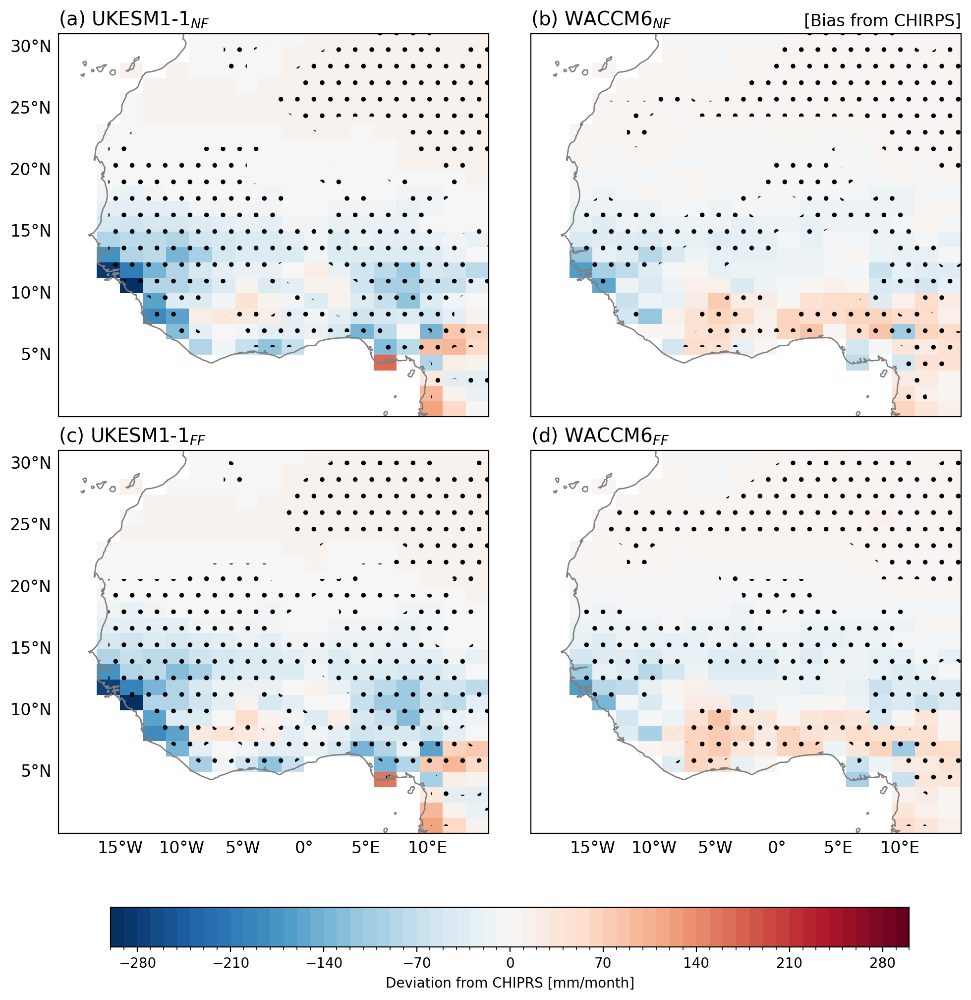

In [192]:
panel_order = [
    ("Near_Future_ukesm_wam", "UKESM1-1$_{NF}$"),
    ("Near_Future_waccm_wam", "WACCM6$_{NF}$"),
    ("Far_Future_ukesm_wam",  "UKESM1-1$_{FF}$"),
    ("Far_Future_waccm_wam",  "WACCM6$_{FF}$"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True,
                        subplot_kw={'projection':ccrs.PlateCarree()})

vmin = min(eval(k).mean("time").min() for k, _ in panel_order)
vmax = max(eval(k).mean("time").max() for k, _ in panel_order)

ct=0
for ax, (key, title) in zip(axes.flat, panel_order):

    da  = eval(key).mean("time") #* 100  #convert to %
    sig = eval(f"sig_{key}")   # boolean DataArray

    # Main field
    pl=da.plot(
        ax=ax,
        cmap="RdBu_r",
        # vmin=vmin,
        # vmax=-vmin,
        levels = np.arange(-300,301,10),
        add_colorbar=False
    )

    # Build a mask array: 1 where significant, NaN elsewhere
    dot_mask = np.where(sig, 1.0, np.nan)
    
    # --- DOT HATCHING USING contourf ---
    # This creates dot stippling ('.' = dotted hatch)
    ax.contourf(
        da['lon'],
        da['lat'],
        dot_mask,
        levels=[0.5, 1.5],
        colors='none',          # no fill, only hatches
        hatches=['.'],       # dot stipple pattern
        alpha=0                # keep background transparent
    )

    ax.set_title(f'({convert(ct)}) {title}', loc='left', fontsize=14)
    ax.set_title('[Bias from CHIRPS]', loc='right') if ct==1 else ax.set_title('')
    ax.set_xlabel("")
    ax.set_ylabel("")
    cart_plot(ax,ct,ncols=2,nrows=2,
              rlon=-20,llon=15,blat=0,tlat=30)
    ct+=1
# =========================
# Shared colorbar
# =========================
cbar = fig.colorbar(pl,
    # plt.cm.ScalarMappable(cmap="RdBu_r"),
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.06
)
cbar.set_label("Deviation from CHIPRS [mm/month]")

# fig.suptitle(
#     "Near and Far Future Precipitation Changes\nStippling denotes p < 0.05",
#     fontsize=14
# )

plt.show()


In [16]:
near_fut = years[:25]
far_fut  = years[25:]

dsnames = ['ukesm_wam', 'waccm_wam']
yr_sep = {'Near_Future': near_fut, 'Far_Future': far_fut}

for dsn in dsnames:
    _use_ds = eval(dsn)

    for yr in yr_sep.keys():

        # Select data
        chirps = chirps_wam['pr']
        model = _use_ds.sel(time=_use_ds.time.dt.year.isin(yr_sep[yr]))['pr'].load()
        chirps['time']= model.time

        # =========================
        # RMSE computation
        # =========================
        rmse = np.sqrt(((model - chirps) ** 2).mean("time"))

        locals()[f'{yr}_{dsn}_rmse'] = rmse


/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


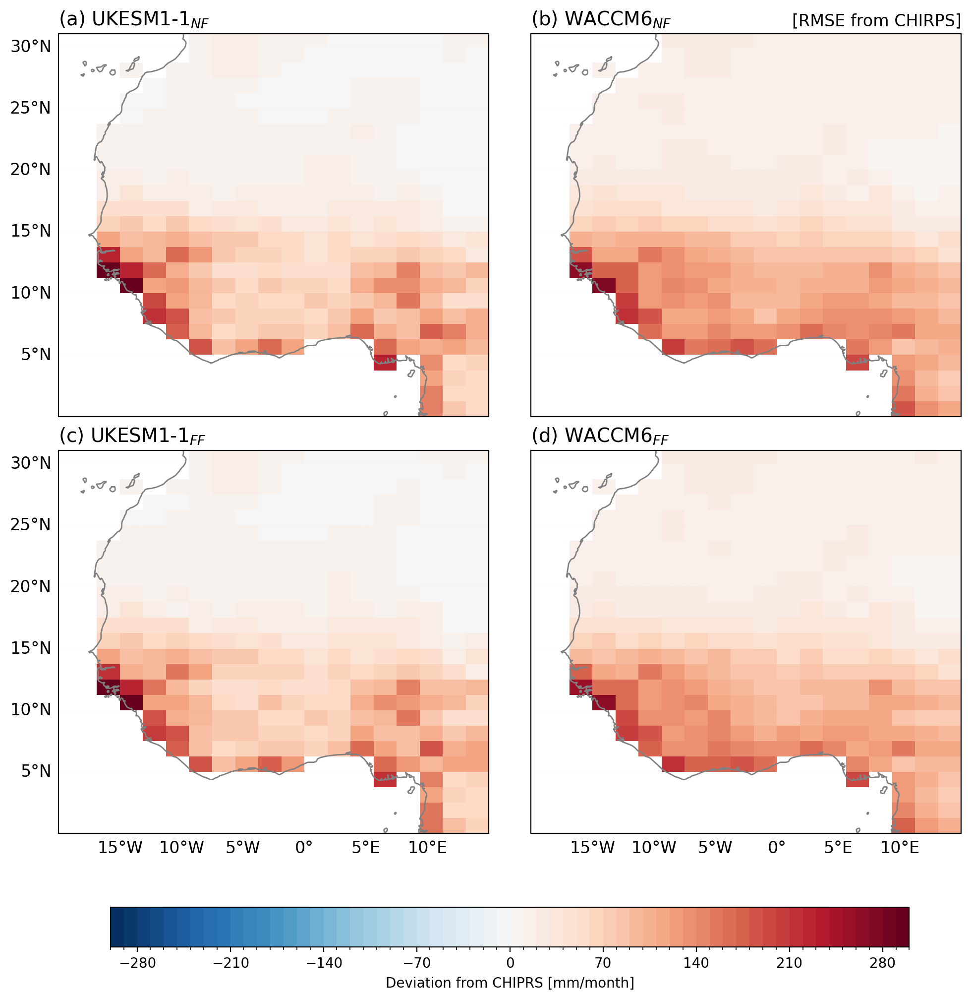

In [194]:
panel_order = [
    ("Near_Future_ukesm_wam_rmse", "UKESM1-1$_{NF}$"),
    ("Near_Future_waccm_wam_rmse", "WACCM6$_{NF}$"),
    ("Far_Future_ukesm_wam_rmse",  "UKESM1-1$_{FF}$"),
    ("Far_Future_waccm_wam_rmse",  "WACCM6$_{FF}$"),
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True,
                        subplot_kw={'projection':ccrs.PlateCarree()})


ct=0
for ax, (key, title) in zip(axes.flat, panel_order):

    da  = eval(key)
    sig = eval(f"sig_{key[:-5]}")   # boolean DataArray

    # Main field
    pl=da.plot(
        ax=ax,
        cmap="RdBu_r",
        # vmin=vmin,
        # vmax=-vmin,
        levels = np.arange(-300,301,10),
        add_colorbar=False
    )

    # Build a mask array: 1 where significant, NaN elsewhere
    # dot_mask = np.where(sig, 1.0, np.nan)
    
    # # --- DOT HATCHING USING contourf ---
    # # This creates dot stippling ('.' = dotted hatch)
    # ax.contourf(
    #     da['lon'],
    #     da['lat'],
    #     dot_mask,
    #     levels=[0.5, 1.5],
    #     colors='none',          # no fill, only hatches
    #     hatches=['.'],       # dot stipple pattern
    #     alpha=0                # keep background transparent
    # )

    ax.set_title(f'({convert(ct)}) {title}', loc='left', fontsize=14)
    ax.set_title('[RMSE from CHIRPS]', loc='right') if ct==1 else ax.set_title('')
    ax.set_xlabel("")
    ax.set_ylabel("")
    cart_plot(ax,ct,ncols=2,nrows=2,
              rlon=-20,llon=15,blat=0,tlat=30)
    ct+=1
# =========================
# Shared colorbar
# =========================
cbar = fig.colorbar(pl,
    # plt.cm.ScalarMappable(cmap="RdBu_r"),
    ax=axes,
    orientation="horizontal",
    fraction=0.05,
    pad=0.06
)
cbar.set_label("Deviation from CHIPRS [mm/month]")

# fig.suptitle(
#     "Near and Far Future Precipitation Changes\nStippling denotes p < 0.05",
#     fontsize=14
# )

plt.show()


Strictly speaking, RMSE itself should not be significance-tested with a t-test, because RMSE is already a nonlinear, aggregated metric.
What you are doing is testing whether the mean model–obs difference is significant, which is acceptable and commonly done — just be clear about this in the paper.

<>:83: SyntaxWarning: invalid escape sequence '\m'
<>:83: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_148/1131646673.py:83: SyntaxWarning: invalid escape sequence '\m'
  cbar0.set_label("$\mathcal{M}$ - CHIRPS [mm/month]",fontsize=14)
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/car

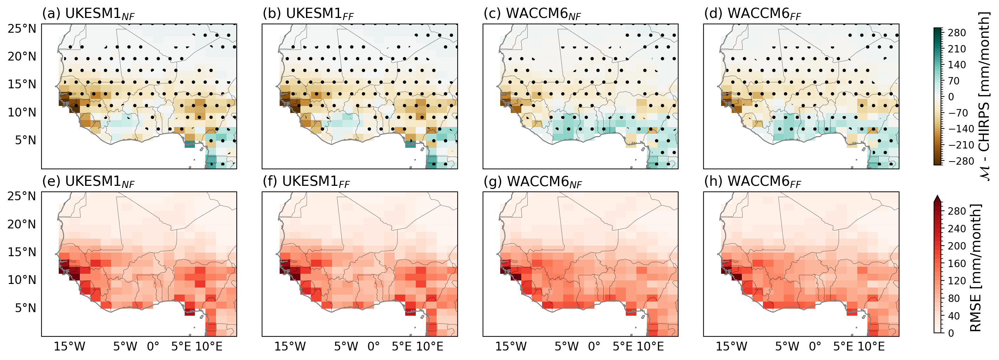

In [18]:
panel_order = [
    ("Near_Future_ukesm_wam", "UKESM1$_{NF}$"),
    ("Far_Future_ukesm_wam",  "UKESM1$_{FF}$"),
    ("Near_Future_waccm_wam", "WACCM6$_{NF}$"),
    ("Far_Future_waccm_wam",  "WACCM6$_{FF}$"),
    ("Near_Future_ukesm_wam_rmse", "UKESM1$_{NF}$"),
    ("Far_Future_ukesm_wam_rmse",  "UKESM1$_{FF}$"),
    ("Near_Future_waccm_wam_rmse", "WACCM6$_{NF}$"),
    ("Far_Future_waccm_wam_rmse",  "WACCM6$_{FF}$"),
]

fig, axes = plt.subplots(
    ncols=4, nrows=2, figsize=(14, 5),
    constrained_layout=True,
    subplot_kw={'projection': ccrs.PlateCarree()}
)

mappable_row0 = None
mappable_row1 = None

ct = 0
for ax, (key, title) in zip(axes.flat, panel_order):

    row = ct // 4  # 0 or 1

    if row == 0:
        da = eval(key).mean("time")
        levels = np.arange(-300, 301, 10)
        cmap = "BrBG"
    else:
        da = eval(key)
        levels = np.arange(0, 301, 10)
        cmap = "Reds"

    pl = da.plot(
        ax=ax,
        cmap=cmap,
        levels=levels,
        add_colorbar=False
    )

    if row == 0:
        mappable_row0 = pl

        sig = eval(f"sig_{key}")
        dot_mask = np.where(sig, 1.0, np.nan)

        ax.contourf(
            da.lon,
            da.lat,
            dot_mask,
            levels=[0.5, 1.5],
            colors='none',
            hatches=['.'],
            alpha=0
        )

    else:
        mappable_row1 = pl

    ax.set_title(f'({convert(ct)}) {title}', loc='left', fontsize=14)
    ax.set_xlabel("")
    ax.set_ylabel("")

    cart_plot(
        ax, ct, ncols=4, nrows=2,
        rlon=-20, llon=15, blat=0, tlat=25
    )

    ct += 1

# =========================
# Colorbar for row 0
# =========================
cbar0 = fig.colorbar(
    mappable_row0,
    ax=axes[0, :],
    orientation="vertical",
    fraction=0.08,
    pad=0.04,
    shrink=0.95 
)
cbar0.set_label("$\mathcal{M}$ - CHIRPS [mm/month]",fontsize=14)

# =========================
# Colorbar for row 1
# =========================
cbar1 = fig.colorbar(
    mappable_row1,
    ax=axes[1, :],
    orientation="vertical",
    fraction=0.08,
    pad=0.04,
    shrink=0.95 
)
cbar1.set_label("RMSE [mm/month]",fontsize=14)
plt.savefig('Images/diff_rmse.png',dpi=200)

plt.show()


Add standard deviation plot as the third panel

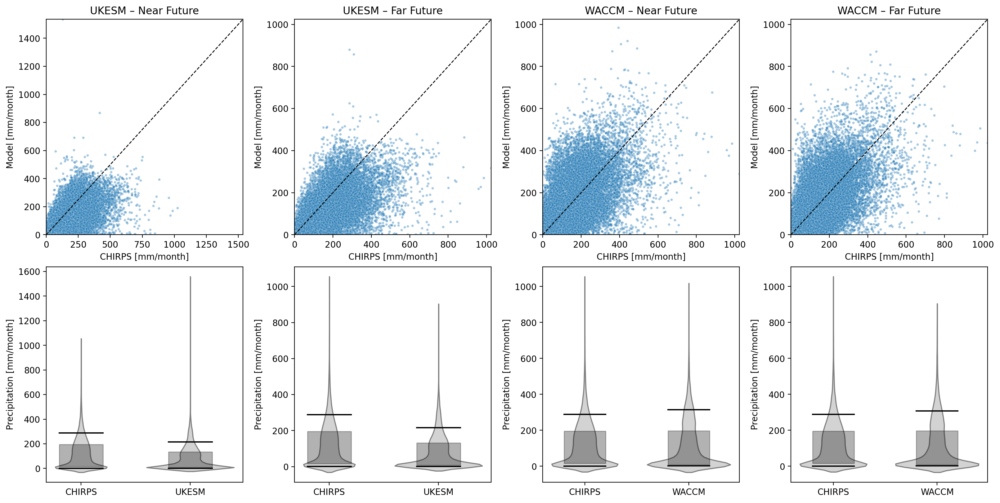

In [230]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import pandas as pd

near_fut = years[:25]
far_fut  = years[25:]

dsnames = ['ukesm_wam', 'waccm_wam']
yr_sep = {'Near Future': near_fut, 'Far Future': far_fut}

fig, axes = plt.subplots(
    nrows=2, ncols=4, figsize=(16, 8),
    constrained_layout=True
)

ct = 0
for dsn in dsnames:
    _use_ds = eval(dsn)

    for yr in yr_sep.keys():

        # =========================
        # Data selection
        # =========================
        chirps = chirps_wam['pr'].sel(
            lat=slice(5, 20), lon=slice(-18, 15)
        )

        model = _use_ds.sel(
            time=_use_ds.time.dt.year.isin(yr_sep[yr])
        )['pr'].sel(
            lat=slice(5, 20), lon=slice(-18, 15)
        ).load()

        chirps['time'] = model.time

        # Flatten & clean
        x = chirps.values.flatten()
        y = model.values.flatten()
        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]

        # =========================
        # TOP ROW: 1–1 scatter
        # =========================
        ax_scatter = axes[0, ct]

        sb.scatterplot(
            x=x, y=y,
            s=8, alpha=0.4,
            ax=ax_scatter
        )

        lims = [min(x.min(), y.min()), max(x.max(), y.max())]
        ax_scatter.plot(lims, lims, 'k--', lw=1)

        ax_scatter.set_xlim(lims)
        ax_scatter.set_ylim(lims)

        ax_scatter.set_title(f"{dsn.split('_')[0].upper()} – {yr}")
        ax_scatter.set_xlabel("CHIRPS [mm/month]")
        ax_scatter.set_ylabel("Model [mm/month]")

        # =========================
        # BOTTOM ROW: Violin + percentiles
        # =========================
        ax_violin = axes[1, ct]

        # Create DataFrame for Seaborn
        df = pd.DataFrame({
            "Precipitation": np.concatenate([x, y]),
            "Dataset": ["CHIRPS"] * len(x) + [dsn.split('_')[0].upper()] * len(y)
        })

        # Violin plot
        sb.violinplot(
            data=df,
            x="Dataset",
            y="Precipitation",
            ax=ax_violin,
            inner=None,   # remove internal box
            color="lightgrey"
        )

        # Overlay 10th-90th percentile boxes
        for i, dset in enumerate(["CHIRPS", dsn.split('_')[0].upper()]):
            vals = df.loc[df["Dataset"]==dset, "Precipitation"].values
            p10, p25, p50, p75, p90 = np.percentile(vals, [10, 25, 50, 75, 90])
            ax_violin.plot([i-0.2, i+0.2], [p10, p10], color="k")   # 10th
            ax_violin.plot([i-0.2, i+0.2], [p90, p90], color="k")   # 90th
            ax_violin.fill_between([i-0.2, i+0.2], p25, p75, color="k", alpha=0.3)  # IQR

        ax_violin.set_xlabel("")
        ax_violin.set_ylabel("Precipitation [mm/month]")

        ct += 1

plt.show()


/tmp/ipykernel_148/1962414764.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(
/tmp/ipykernel_148/1962414764.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(
/tmp/ipykernel_148/1962414764.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(
/tmp/ipykernel_148/1962414764.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(


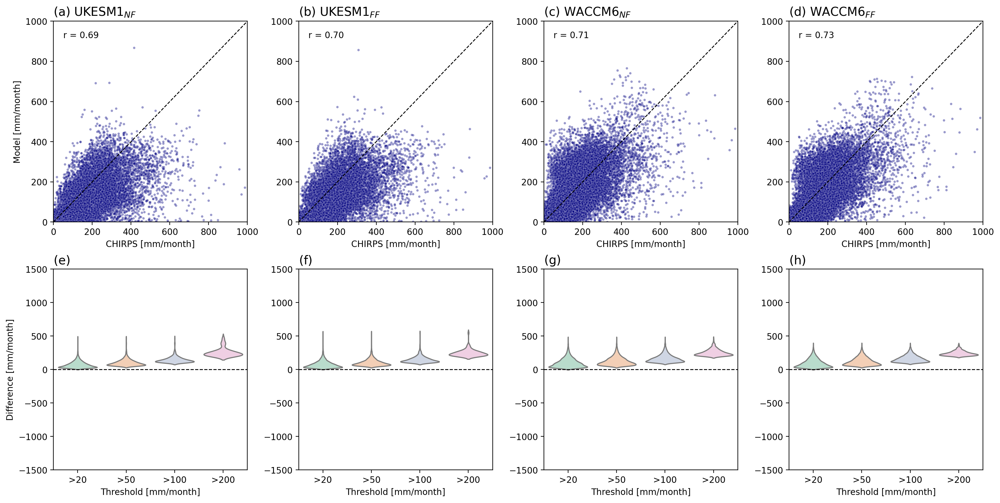

In [20]:
near_fut = years[:25]
far_fut  = years[25:]

dsnames = ['ukesm_wam', 'waccm_wam']
yr_sep = {'Near Future': near_fut, 'Far Future': far_fut}

# Precipitation thresholds
thresholds = [20, 50, 100, 200]

fig, axes = plt.subplots(
    nrows=2, ncols=4, figsize=(16, 8),
    constrained_layout=True
)

ct = 0
for dsn in dsnames:
    _use_ds = eval(dsn)

    for yr in yr_sep.keys():

        # =========================
        # Data selection
        # =========================
        chirps = chirps_wam['pr'].sel(
            lat=slice(5, 20), lon=slice(-18, 15)
        )

        model = _use_ds.sel(
            time=_use_ds.time.dt.year.isin(yr_sep[yr])
        )['pr'].sel(
            lat=slice(5, 20), lon=slice(-18, 15)
        ).load()

        chirps['time'] = model.time

        # Flatten & clean
        x = chirps.values.flatten()
        y = model.values.flatten()
        mask = np.isfinite(x) & np.isfinite(y)
        x, y = x[mask], y[mask]

        # =========================
        # Top row: 1–1 scatter
        # =========================
        ax_scatter = axes[0, ct]
        
        sb.scatterplot(
            x=x, y=y,
            s=8, alpha=0.4,
            ax=ax_scatter,
            color='navy'
        )
        
        lims = [min(x.min(), y.min()), max(x.max(), y.max())]
        lims = [0,1000]
        ax_scatter.plot(lims, lims, 'k--', lw=1)
        ax_scatter.set_xlim(lims)
        ax_scatter.set_ylim(lims)
        # ax_scatter.set_title(f"({convert(ct)}) {dsn.split('_')[0].upper()} – {yr}", loc='left', fontsize=14)
        ax_scatter.set_title(
            f"({convert(ct)}) {'UKESM1' if 'ukesm' in dsn else 'WACCM6'}$_{{{'NF' if yr=='Near Future' else 'FF'}}}$",
            loc='left', fontsize=14
        )
        ax_scatter.set_xlabel("CHIRPS [mm/month]")
        ax_scatter.set_ylabel("Model [mm/month]") if ct%4==0 else ax_scatter.set_ylabel('')
        
        # ---- Add Pearson r ----
        r, _ = pearsonr(x, y)
        ax_scatter.text(0.05, 0.95, f"r = {r:.2f}",
                        transform=ax_scatter.transAxes,
                        fontsize=10, verticalalignment='top',
                        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

        # =========================
        # Bottom row: Violin plots for thresholds (model - CHIRPS)
        # =========================
        ax_violin = axes[1, ct]

        diff_data = []
        labels = []

        for thresh in thresholds:
            diff_all = y - x                    # model − CHIRPS
            mask_thresh = diff_all > thresh     # threshold on the difference
            diff = diff_all[mask_thresh]
        
            diff_data.append(diff)
            labels.append(f">{thresh}")

        # Build DataFrame for seaborn
        dataset_labels = np.repeat(labels, [len(d) for d in diff_data])
        df = pd.DataFrame({
            "Difference (Model - CHIRPS)": np.concatenate(diff_data),
            "Threshold": dataset_labels
        })

        sb.violinplot(
            data=df,
            x="Threshold",
            y="Difference (Model - CHIRPS)",
            ax=ax_violin,
            inner=None,
            palette="Pastel2"
        )

        ax_violin.axhline(0, color='k', lw=1, linestyle='--')
        ax_violin.set_ylabel("Difference [mm/month]") if ct%4==0 else ax_violin.set_ylabel('')
        ax_violin.set_xlabel("Threshold [mm/month]")
        # ax_violin.set_title(f"({convert(ct+4)})", loc='left', fontsize=14)
        ax_violin.set_title(
            f"({convert(ct+4)}) $_{{{'' if yr=='Near Future' else ''}}}$",
            loc='left', fontsize=14
        )

        # ax_violin.set_xticklabels(ax_violin.get_xticklabels(), rotation=45, ha='right')
        ax_violin.set_ylim(-1500,1500)
        ct += 1

plt.savefig('Images/dist_1_1_plot.png',dpi=200)
plt.show()


## ETCCDI Metrics for Precipitation Analyses

In [21]:
import xclim as xc

In [22]:
## Load this helper function

def open_s3_xarray_ukesm(bucket, group, scenario, variable_name, partial_filename, anon=False):
    fs = s3fs.S3FileSystem(anon=anon)
    keys = fs.glob(f"{bucket}/{group}/{scenario}/{variable_name}_{partial_filename}*.nc")
    urls = [f"simplecache::s3://{k}" for k in keys][:2]
    print(f"{bucket}/{group}/{scenario}/{variable_name}_{partial_filename}*.nc")
    ds = xr.open_mfdataset(
        urls,
        engine="h5netcdf",
        combine="by_coords",
        parallel=True,
        backend_kwargs={
            "storage_options": {
                "s3": {"anon": anon},
                "simplecache": {"cache_storage": "/tmp/s3cache"},
            }
        },
    )
    lon_names = ['longitude', 'lon']
    lon_name = [ln for ln in lon_names if ln in ds][0]
    
    lat_names = ['latitude', 'lat']
    lat_name = [lt for lt in lat_names if lt in ds][0]
    print(lat_name)
    
    # ds = ds.assign_coords({lon_name:((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    ds = ds.assign_coords({lon_name: ((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    if lon_name != "lon":
        ds = ds.rename({lon_name: "lon", lat_name:"lat"})
    
    return ds#.load()


## Load this helper function

def open_s3_xarray_waccm(bucket, group, scenario, variable_name, partial_filename, anon=False):
    fs = s3fs.S3FileSystem(anon=anon)
    keys = fs.glob(f"{bucket}/{group}/{scenario}{variable_name}{partial_filename}.*.nc")
    urls = [f"simplecache::s3://{k}" for k in keys]
    urls.sort()
    print(urls)
    print(f"{bucket}/{group}/{scenario}{variable_name}{partial_filename}*.nc")
    ds = [xr.open_mfdataset(
        [url],
        engine="h5netcdf",
        combine="by_coords",
        parallel=True,
        backend_kwargs={
            "storage_options": {
                "s3": {"anon": anon},
                "simplecache": {"cache_storage": "/tmp/s3cache"},
            }
        },
    )[['PRECT']] for url in urls]

    print(ds[-1])
    ds[-1] = ds[-1].sel(time=slice("2080","2084"))
    
    ds = xr.concat(ds,dim='time')
    lon_names = ['longitude', 'lon']
    lon_name = [ln for ln in lon_names if ln in ds][0]
    
    lat_names = ['latitude', 'lat']
    lat_name = [lt for lt in lat_names if lt in ds][0]
    print(lat_name)
    
    # ds = ds.assign_coords({lon_name:((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    ds = ds.assign_coords({lon_name: ((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    if lon_name != "lon":
        ds = ds.rename({lon_name: "lon", lat_name:"lat"})
    
    return ds


def cart_plot(axes,ix, ncols=3,nrows=3, rlon=-150,llon=-60,tlat=42,blat=15):
    axes.add_feature(cf.BORDERS,linewidth=0.2) #add features (boarders )
    axes.add_feature(cf.COASTLINE,linewidth=1,color='gray') #coastlines 
    gl=axes.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.01, linestyle='--') #create the map type with grids 
    axes.set_extent([llon,rlon,blat,tlat]) #set the extent of the map
    if ix%ncols ==0:
        
        gl.top_labels = False; gl.left_labels = True #set which axis labels should show 
        gl.right_labels=False; gl.xlines = False; gl.bottom_labels=False

    elif ix>=(ncols*nrows)-ncols:
        gl.top_labels = False; gl.left_labels = False #set which axis labels should show 
        gl.right_labels=False; gl.xlines = False; gl.bottom_labels=True

    else:
        gl.top_labels = False; gl.left_labels = False #set which axis labels should show 
        gl.right_labels=False; gl.xlines = False; gl.bottom_labels=False
    if ix == (ncols*nrows)-ncols:
        gl.top_labels = False; gl.left_labels = True #set which axis labels should show 
        gl.right_labels=False; gl.xlines = False; gl.bottom_labels=True
    axes.xformatter = LONGITUDE_FORMATTER;  axes.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'color':'black','size':12} #change font style for x-axis 
    gl.ylabel_style = {'color':'black','size':12}#change font style for y-axis  

convert = lambda x: chr(ord('`')+(x+1)) if x<26 else chr(ord('`')+((x)//25))+chr(ord('`')+(x+1)%26)

In [41]:
# Connect to AWS S3 storage and load WACCM historical Precipitation 
fs = s3fs.S3FileSystem(anon=True)

# load catalogue
df = pd.read_csv("https://cmip6-pds.s3.amazonaws.com/pangeo-cmip6.csv")

# subset the archive
df_subset = df.query(
    "activity_id=='CMIP'& source_id=='CESM2-WACCM' & \
    experiment_id=='historical' & table_id=='day' & \
    variable_id=='pr'")

# get the path to a specific zarr store
zstores = df_subset.zstore.values
zstores

array(['s3://cmip6-pds/CMIP6/CMIP/NCAR/CESM2-WACCM/historical/r2i1p1f1/day/pr/gn/v20190415/',
       's3://cmip6-pds/CMIP6/CMIP/NCAR/CESM2-WACCM/historical/r3i1p1f1/day/pr/gn/v20190415/',
       's3://cmip6-pds/CMIP6/CMIP/NCAR/CESM2-WACCM/historical/r1i1p1f1/day/pr/gn/v20190415/'],
      dtype=object)

In [42]:
lon_slice = slice(-25, 25)
lat_slice = slice(0,35)
time_slice = slice("1981","2014")

In [43]:
lon_name = 'lon'
lat_name = 'lat'
waccm_hist_out = []
for zstore in zstores:
    
    waccm_r = xr.open_dataset(
        zstore,
        engine="zarr",
        consolidated=True,
        chunks={},                        # or {} / None or 'auto' as you prefer
        storage_options={"anon": True}).assign_coords({lon_name: lambda ds: ((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name).sel({
        "time" : time_slice,
        lon_name : lon_slice, 
        lat_name : lat_slice}).load()* 24 * 60 * 60 * 31
    waccm_hist_out.append(waccm_r)
waccm_hist_pr = xr.concat(waccm_hist_out, dim='ensembles').mean('ensembles')

In [38]:
# Connect to AWS S3 storage and load UKESM historical Precipitation 
fs = s3fs.S3FileSystem(anon=True)

# load catalogue
df = pd.read_csv("https://cmip6-pds.s3.amazonaws.com/pangeo-cmip6.csv")

# subset the archive
df_subset = df.query(
    "activity_id=='CMIP'& source_id=='UKESM1-0-LL' & \
    experiment_id=='historical' & table_id=='day' & \
    variable_id=='pr'")

# get the path to a specific zarr store
zstores = df_subset.zstore.values
zstores

array(['s3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/day/pr/gn/v20190627/',
       's3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r3i1p1f2/day/pr/gn/v20190708/',
       's3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r8i1p1f2/day/pr/gn/v20190708/',
       's3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r4i1p1f2/day/pr/gn/v20190708/',
       's3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r2i1p1f2/day/pr/gn/v20190708/',
       's3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r7i1p1f3/day/pr/gn/v20191011/',
       's3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r9i1p1f2/day/pr/gn/v20191015/',
       's3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r6i1p1f3/day/pr/gn/v20191113/',
       's3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r5i1p1f3/day/pr/gn/v20191115/',
       's3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r17i1p1f2/day/pr/gn/v20191115/',
       's3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historic

In [40]:
lon_name = 'lon'
lat_name = 'lat'
ukesm_hist_out = []
for zstore in zstores:
    
    ukesm_r = xr.open_dataset(
        zstore,
        engine="zarr",
        consolidated=True,
        chunks={},                        # or {} / None or 'auto' as you prefer
        storage_options={"anon": True}).assign_coords({lon_name: lambda ds: ((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name).sel({
        "time" : time_slice,
        lon_name : lon_slice, 
        lat_name : lat_slice}).load() * 24 * 60 * 60 * 31
    ukesm_hist_out.append(ukesm_r)

ukesm_hist_pr = xr.concat(ukesm_hist_out, dim='ensembles').mean('ensembles')

In [44]:
waccm_hist = waccm_hist_pr.sel(time=waccm_hist_pr.time.dt.month.isin([6,7,8,9]))
ukesm_hist = ukesm_hist_pr.sel(time=ukesm_hist_pr.time.dt.month.isin([6,7,8,9]))


In [24]:
sim_time = slice("2035","2085")
_lon_slice, _lat_slice = slice(-25,30), slice(0,35)

In [25]:
ukesm_e1 = open_s3_xarray_ukesm(
    bucket="reflective-persistent-prod-large",
    group="UKESM1-1",
    scenario="G6-1p5K-HiLLA/r12i1p1f2/apj/day/pr",
    variable_name="pr",
    partial_filename="day_UKESM1-1-LL_g6-1p5-hilla_r12i1p1f2_gn",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)

ukesm_e2 = open_s3_xarray_ukesm(
    bucket="reflective-persistent-prod-large",
    group="UKESM1-1",
    scenario="G6-1p5K-HiLLA/r2i1p1f2/apj/day/pr",
    variable_name="pr",
    partial_filename="day_UKESM1-1-LL_g6-1p5-hilla_r2i1p1f2_gn",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)

ukesm_e3 = open_s3_xarray_ukesm(
    bucket="reflective-persistent-prod-large",
    group="UKESM1-1",
    scenario="G6-1p5K-HiLLA/r3i1p1f2/apj/day/pr",
    variable_name="pr",
    partial_filename="day_UKESM1-1-LL_g6-1p5-hilla_r3i1p1f2_gn",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)

reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r12i1p1f2/apj/day/pr/pr_day_UKESM1-1-LL_g6-1p5-hilla_r12i1p1f2_gn*.nc
lat
reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r2i1p1f2/apj/day/pr/pr_day_UKESM1-1-LL_g6-1p5-hilla_r2i1p1f2_gn*.nc
lat
reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r3i1p1f2/apj/day/pr/pr_day_UKESM1-1-LL_g6-1p5-hilla_r3i1p1f2_gn*.nc
lat


In [26]:
## Compute ensemble avg for ensemble members
ukesm_ens = xr.concat([ukesm_e1['pr'],ukesm_e2['pr'],ukesm_e2['pr']], dim='ensembles')
ukesm_agv = (ukesm_e1['pr']+ukesm_e2['pr']+ukesm_e2['pr'])/3

In [27]:
ukesm_ens_std = ukesm_ens.mean('time').std('ensembles')

In [16]:
ukesm_ens_std.load()#.plot()


KeyboardInterrupt



In [28]:
ukesm_agv = ukesm_agv.to_dataset(name='pr')

In [29]:
sim_time = slice("2035","2084")
_lon_slice, _lat_slice = slice(-25,30), slice(0,35)

waccm_e1 = open_s3_xarray_waccm(
    bucket="reflective-persistent-prod-large",
    group="CESM2-WACCM",
    scenario="G6-1.5k-HiLLA/r1/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h1.",
    variable_name="PRECT",
    partial_filename="",
).sel( lon=_lon_slice, lat=_lat_slice)[['PRECT']]


waccm_e2 = open_s3_xarray_waccm(
    bucket="reflective-persistent-prod-large",
    group="CESM2-WACCM",
    scenario="G6-1.5k-HiLLA/r2/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.002.cam.h1.",
    variable_name="PRECT",
    partial_filename="",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)[['PRECT']]

waccm_e3 = open_s3_xarray_waccm(
    bucket="reflective-persistent-prod-large",
    group="CESM2-WACCM",
    scenario="G6-1.5k-HiLLA/r3/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.003.cam.h1.",
    variable_name="PRECT",
    partial_filename="",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)[['PRECT']]

# ukesm_e1 = open_s3_xarray(
#     bucket="reflective-persistent-prod-large",
#     group="UKESM1-1",
#     scenario="G6-1p5K-HiLLA/r2i1p1f2/apm/Amon/pr",
#     variable_name="pr",
#     partial_filename="Amon_UKESM1-1-LL_g6-1p5-hilla_r2i1p1f2_gn",
# ).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)

['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h1.PRECT.20350101-20391231.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h1.PRECT.20391231-20500105.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h1.PRECT.20500101-20600105.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h1.PRECT.20600101-20700105.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h1.PRECT.20700101-20800105.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h1.PRECT.20800101-20841231.nc']
reflective-pers

In [30]:
def drop_duplicate_times(ds):
    _, unique_idx = np.unique(ds.time.values, return_index=True)
    return ds.isel(time=np.sort(unique_idx))

waccm_e1 = drop_duplicate_times(waccm_e1)
waccm_ens = xr.concat([waccm_e1['PRECT'],waccm_e2['PRECT'],waccm_e3['PRECT']],dim='ensembles')
waccm_agv = (waccm_e1['PRECT']+waccm_e2['PRECT']+waccm_e3['PRECT'])/3

In [31]:
_lon_slice, _lat_slice = slice(-25,30), slice(0,35)

mask = xr.open_mfdataset('africa_mask.nc')['rain'].assign_coords( longitude=(
            lambda ds: (ds.lon + 180) % 360 - 180)).sortby(
            lambda ds: ds['lon']).sel(lon=_lon_slice, lat=_lat_slice).interp_like(ukesm_agv['pr'])

In [32]:

mask

lons,lats = ukesm_agv.lon.values, ukesm_agv.lat.values

In [33]:
import numpy as np
from itertools import groupby

def count_consecutive_threshold_chunks1(arr, threshold, n_cons_thresh):
    """
    Count consecutive runs where arr >= threshold
    and run length > n_cons_thresh
    """
    mask = arr >= threshold

    chunks = [list(group) for key, group in groupby(mask) if key]
    valid_chunks = [ch for ch in chunks if len(ch) > n_cons_thresh]

    return np.int32(len(valid_chunks))


In [34]:
import numpy as np
from itertools import groupby

def count_consecutive_threshold_chunks(arr, threshold, n_cons_thresh):
    """
    Count consecutive runs where arr >= threshold
    and run length > n_cons_thresh
    """
    mask = arr >= threshold

    chunks = [list(group) for key, group in groupby(mask) if key]
    valid_chunks = [len(ch) for ch in chunks if len(ch) > n_cons_thresh]
    # print(valid_chunks)
    return np.int32(max(valid_chunks)) if len(valid_chunks) != 0 else 0


In [35]:
# _use = (waccm_agv).load()
waccm_loaded = (waccm_ens.interp({'lon':lons,'lat':lats}).where(mask>0)).load()
ukesm_loaded = ukesm_ens.interp({'lon':lons,'lat':lats}).where(mask>0).load()

In [36]:
# _use = (waccm_agv).load()
waccm_loaded_av = (waccm_agv.interp({'lon':lons,'lat':lats}).where(mask>0)).load()
ukesm_loaded_av = ukesm_agv['pr'].interp({'lon':lons,'lat':lats}).where(mask>0).load()

In [45]:
# _use = (waccm_agv).load()
waccm_hist = (waccm_hist_pr['pr'].interp({'lon':lons,'lat':lats}).where(mask>0))#.load()
ukesm_hist = ukesm_hist_pr['pr'].interp({'lon':lons,'lat':lats}).where(mask>0)#.load()

In [48]:
from tqdm import tqdm

In [70]:

waccm_sai_ = waccm_loaded_av.sel(time=waccm_loaded_av.time.dt.month.isin([6,7,8,9])) * 24 * 60 * 60 *1000
ukesm_sai_ = ukesm_loaded_av.sel(time=ukesm_loaded_av.time.dt.month.isin([6,7,8,9])) * 24 * 60 * 60

waccm_hist_ = waccm_hist.sel(time=waccm_hist.time.dt.month.isin([6,7,8,9]))/31# * 24 * 60 * 60 *1000
ukesm_hist_ = ukesm_hist.sel(time=ukesm_hist.time.dt.month.isin([6,7,8,9]))/31# * 24 * 60 * 60

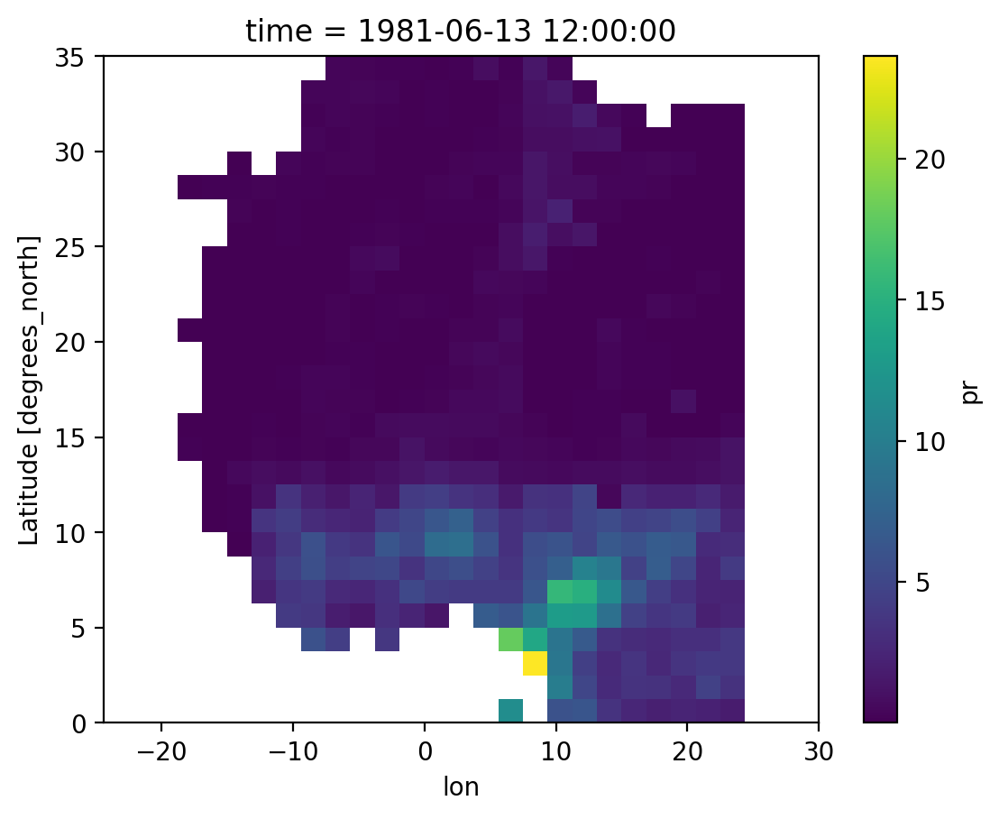

In [69]:
(ukesm_hist_[12]/31).plot()

### CWD 

#### HISTORICAL CWD

In [71]:
threshold = 1
n_cons_thresh = 3
waccm_cwd_hist = []
ukesm_cwd_hist = []
datasets = {'waccm':waccm_hist_,
            'ukesm':ukesm_hist_}

years = np.arange(1981,2014)
for dset in tqdm(datasets.keys()):
    
    for yy in years:
        ds__ = datasets[dset].sel(time=str(yy))
        out = xr.apply_ufunc(
            count_consecutive_threshold_chunks,
            ds__ ,
            input_core_dims=[["time"]],
            output_core_dims=[[]],          # scalar output
            vectorize=True,
            dask="parallelized",
            output_dtypes=[np.int32],
            kwargs={
                "threshold": threshold,
                "n_cons_thresh": n_cons_thresh
            }
        )
        eval(f'{dset}_cwd_hist').append(out)

100%|██████████| 2/2 [00:00<00:00,  7.90it/s]


#### SAI CWD

In [72]:
threshold = 1
n_cons_thresh = 3
waccm_cwd = []
ukesm_cwd = []
datasets = {'waccm':waccm_sai_,
            'ukesm':ukesm_sai_}

years = np.arange(2035,2085)
for dset in tqdm(datasets.keys()):
    
    for yy in years:
        ds__ = datasets[dset].sel(time=str(yy))
        out = xr.apply_ufunc(
            count_consecutive_threshold_chunks,
            ds__ ,
            input_core_dims=[["time"]],
            output_core_dims=[[]],          # scalar output
            vectorize=True,
            dask="parallelized",
            output_dtypes=[np.int32],
            kwargs={
                "threshold": threshold,
                "n_cons_thresh": n_cons_thresh
            }
        )
        eval(f'{dset}_cwd').append(out)

100%|██████████| 2/2 [00:01<00:00,  1.06it/s]


In [73]:
waccm_cwd#.plot()

[<xarray.DataArray 'PRECT' (lat: 28, lon: 29)> Size: 3kB
 array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,  22,   0,  54,  53,  30,  28,  49,  49,  54,  53,
          70,  77,  38],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0, 122,  66,  30,  50,  51,  49,  49,  54,
          84, 122,  38],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0, 122, 122,  51,  50,  50,  49,  73,  49,  49,
          81, 122,  38],
        [  0,   0,   0,   0,   0,   0,   0,   0,  62,  62,   0,  48,   0,
           0,   0,   0, 122, 122, 122, 122, 122, 122,  75,  75,  86,  49,
         100, 100,  79],
        [  0,   0,   0,   0,   0,   0,   0, 122,  78,  78,  75,  67,  67,
          62,   0,  62, 122, 122, 122, 122, 122, 122,  87,  75,  86,  66,
          50, 100,  56],
        [  0,   0,   0,   0,   0,   0, 122, 122, 122, 122,  86,  75,  75,
    

In [52]:
waccm_cwd#.plot()

[<xarray.DataArray 'PRECT' (lat: 28, lon: 29)> Size: 3kB
 array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,  22,   0,  54,  53,  30,  28,  49,  49,  54,  53,
          70,  77,  38],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0, 122,  66,  30,  50,  51,  49,  49,  54,
          84, 122,  38],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0, 122, 122,  51,  50,  50,  49,  73,  49,  49,
          81, 122,  38],
        [  0,   0,   0,   0,   0,   0,   0,   0,  62,  62,   0,  48,   0,
           0,   0,   0, 122, 122, 122, 122, 122, 122,  75,  75,  86,  49,
         100, 100,  79],
        [  0,   0,   0,   0,   0,   0,   0, 122,  78,  78,  75,  67,  67,
          62,   0,  62, 122, 122, 122, 122, 122, 122,  87,  75,  86,  66,
          50, 100,  56],
        [  0,   0,   0,   0,   0,   0, 122, 122, 122, 122,  86,  75,  75,
    

/tmp/ipykernel_417/2504936733.py:54: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  lambda x: ttest_1samp(x, popmean=0, nan_policy='omit')[1],
/srv/conda/envs/notebook/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will ha

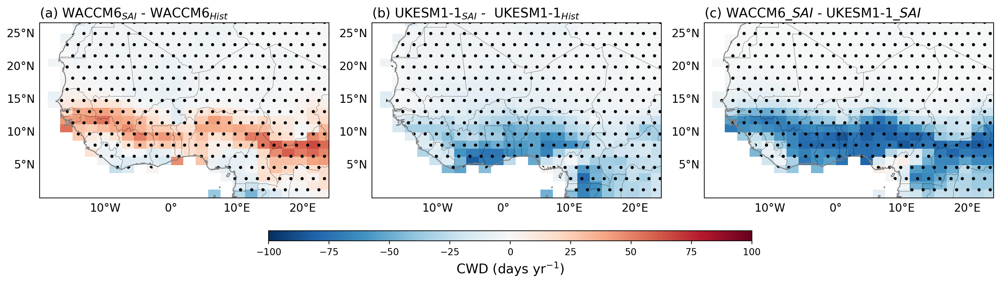

In [45]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.stats import ttest_1samp

# -----------------------------
# Compute historical mean
# -----------------------------
conc_waccm_hist_mean = xr.concat(waccm_cwd_hist, dim='members').mean('members').where(mask>0)
conc_ukesm_hist_mean = xr.concat(ukesm_cwd_hist, dim='members').mean('members').where(mask>0)

# -----------------------------
# Compute SAI ensembles
# -----------------------------
conc_waccm_sai = xr.concat(waccm_cwd, dim='members').where(mask>0)
conc_ukesm_sai = xr.concat(ukesm_cwd, dim='members').where(mask>0)

# -----------------------------
# Difference (SAI - Hist Mean)
# -----------------------------
diff_waccm = conc_waccm_sai - conc_waccm_hist_mean
diff_ukesm = conc_ukesm_sai - conc_ukesm_hist_mean
diff_models = conc_ukesm_sai - conc_waccm_sai

diff_waccm.load().where(mask>0)
diff_ukesm.load().where(mask>0)
diff_models.load().where(mask>0)
# -----------------------------
# Compute mean for plotting
# -----------------------------
data_list = [
    diff_waccm.mean('members'),
    diff_ukesm.mean('members'),
    diff_models.mean('members')
]

titles = [
    r"(a) WACCM6$_{SAI}$ - WACCM6$_{Hist}$",
    r"(b) UKESM1-1$_{SAI}$ -  UKESM1-1$_{Hist}$",
    r"(c) WACCM6_$SAI$ - UKESM1-1_$SAI$ "
]

cmaps = ["RdBu_r", "RdBu_r", "RdBu_r"]
vmin, vmax = -100, 100
dmax = 100
vlims = [(vmin, vmax), (vmin, vmax), (-dmax, dmax)]

# -----------------------------
# Significance function
# -----------------------------
def ttest_pval(da):
    return xr.apply_ufunc(
        lambda x: ttest_1samp(x, popmean=0, nan_policy='omit')[1],
        da,
        input_core_dims=[['members']],
        vectorize=True
    )

signif_waccm = ttest_pval(diff_waccm) < 0.05
signif_ukesm = ttest_pval(diff_ukesm) < 0.05
signif_models = ttest_pval(diff_models) < 0.05
signif_list = [signif_waccm, signif_ukesm, signif_models]

# -----------------------------
# Plotting
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': ccrs.PlateCarree()})
mappables = []

for da, signif, ax, title, cmap, (v0, v1) in zip(data_list, signif_list, axes, titles, cmaps, vlims):

    # Mean difference
    im = da.plot(ax=ax, cmap=cmap, vmin=v0, vmax=v1, add_colorbar=False, transform=ccrs.PlateCarree())
    
    # Overlay stippling using xarray-style contourf
    signif.where(mask>0).plot.contourf(
        ax=ax,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['.'],
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(title, loc='left', fontsize=14)
    ax.set_title('')
    mappables.append(im)
    cart_plot(ax, 0, ncols=3, nrows=1, llon=-20, rlon=24, blat=0, tlat=25)

# Shared colorbar
cax1 = fig.add_axes([0.27, 0.11, 0.48, 0.03])
cbar1 = fig.colorbar(mappables[0], cax=cax1, orientation='horizontal')
cbar1.set_label("CWD (days yr$^{-1}$)", fontsize=14)

plt.tight_layout()
# plt.savefig('Images/CWD_sig_diffs.png')

plt.show()


/tmp/ipykernel_148/919711394.py:54: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  lambda x: ttest_1samp(x, popmean=0, nan_policy='omit')[1],
/srv/conda/envs/notebook/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will hav

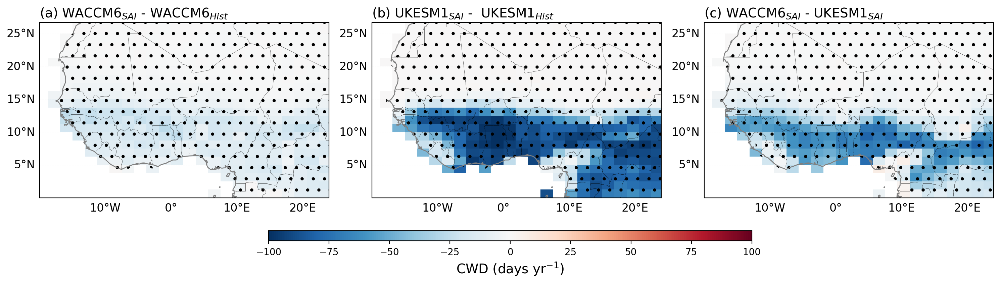

In [77]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.stats import ttest_1samp

# -----------------------------
# Compute historical mean
# -----------------------------
conc_waccm_hist_mean = xr.concat(waccm_cwd_hist, dim='members').mean('members').where(mask>0)
conc_ukesm_hist_mean = xr.concat(ukesm_cwd_hist, dim='members').mean('members').where(mask>0)

# -----------------------------
# Compute SAI ensembles
# -----------------------------
conc_waccm_sai = xr.concat(waccm_cwd, dim='members').where(mask>0)
conc_ukesm_sai = xr.concat(ukesm_cwd, dim='members').where(mask>0)

# -----------------------------
# Difference (SAI - Hist Mean)
# -----------------------------
diff_waccm = conc_waccm_sai - conc_waccm_hist_mean
diff_ukesm = conc_ukesm_sai - conc_ukesm_hist_mean
diff_models = conc_ukesm_sai - conc_waccm_sai

diff_waccm.load().where(mask>0)
diff_ukesm.load().where(mask>0)
diff_models.load().where(mask>0)
# -----------------------------
# Compute mean for plotting
# -----------------------------
data_list = [
    diff_waccm.mean('members'),
    diff_ukesm.mean('members'),
    diff_models.mean('members')
]

titles = [
    r"(a) WACCM6$_{SAI}$ - WACCM6$_{Hist}$",
    r"(b) UKESM1$_{SAI}$ -  UKESM1$_{Hist}$",
    r"(c) WACCM6$_{SAI}$ - UKESM1$_{SAI}$ "
]

cmaps = ["RdBu_r", "RdBu_r", "RdBu_r"]
vmin, vmax = -100, 100
dmax = 100
vlims = [(vmin, vmax), (vmin, vmax), (-dmax, dmax)]

# -----------------------------
# Significance function
# -----------------------------
def ttest_pval(da):
    return xr.apply_ufunc(
        lambda x: ttest_1samp(x, popmean=0, nan_policy='omit')[1],
        da,
        input_core_dims=[['members']],
        vectorize=True
    )

signif_waccm = ttest_pval(diff_waccm) < 0.05
signif_ukesm = ttest_pval(diff_ukesm) < 0.05
signif_models = ttest_pval(diff_models) < 0.05
signif_list = [signif_waccm, signif_ukesm, signif_models]

# -----------------------------
# Plotting
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': ccrs.PlateCarree()})
mappables = []

for da, signif, ax, title, cmap, (v0, v1) in zip(data_list, signif_list, axes, titles, cmaps, vlims):

    # Mean difference
    im = da.plot(ax=ax, cmap=cmap, vmin=v0, vmax=v1, add_colorbar=False, transform=ccrs.PlateCarree())
    
    # Overlay stippling using xarray-style contourf
    signif.where(mask>0).plot.contourf(
        ax=ax,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['.'],
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(title, loc='left', fontsize=14)
    ax.set_title('')
    mappables.append(im)
    cart_plot(ax, 0, ncols=3, nrows=1, llon=-20, rlon=24, blat=0, tlat=25)

# Shared colorbar
cax1 = fig.add_axes([0.27, 0.11, 0.48, 0.03])
cbar1 = fig.colorbar(mappables[0], cax=cax1, orientation='horizontal')
cbar1.set_label("CWD (days yr$^{-1}$)", fontsize=14)

plt.tight_layout()
plt.savefig('Images/CWD_sig_diffs_v2.png')

plt.show()


/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp/ipykernel_417/309919290.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


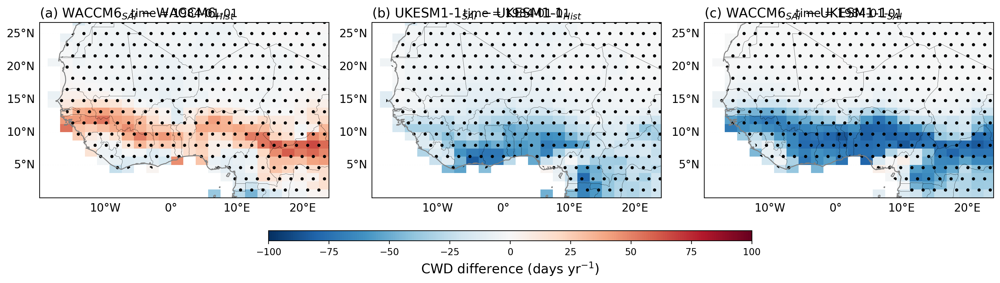

In [55]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pymannkendall as mk

# -----------------------------
# Compute historical mean
# -----------------------------
conc_waccm_hist_mean = (
    xr.concat(waccm_cwd_hist, dim="members")
    .mean("members")
    .where(mask > 0)
)

conc_ukesm_hist_mean = (
    xr.concat(ukesm_cwd_hist, dim="members")
    .mean("members")
    .where(mask > 0)
)

# -----------------------------
# Compute SAI ensembles
# -----------------------------
conc_waccm_sai = xr.concat(waccm_cwd, dim="members").where(mask > 0)
conc_ukesm_sai = xr.concat(ukesm_cwd, dim="members").where(mask > 0)

# -----------------------------
# Differences (SAI − Hist Mean)
# -----------------------------
diff_waccm  = conc_waccm_sai - conc_waccm_hist_mean
diff_ukesm  = conc_ukesm_sai - conc_ukesm_hist_mean
diff_models = conc_ukesm_sai - conc_waccm_sai

# -----------------------------
# Mean difference for shading
# -----------------------------
data_list = [
    diff_waccm.mean("members"),
    diff_ukesm.mean("members"),
    diff_models.mean("members"),
]

titles = [
    r"(a) WACCM6$_{SAI}$ − WACCM6$_{Hist}$",
    r"(b) UKESM1-1$_{SAI}$ − UKESM1-1$_{Hist}$",
    r"(c) WACCM6$_{SAI}$ − UKESM1-1$_{SAI}$",
]

cmaps = ["RdBu_r", "RdBu_r", "RdBu_r"]
vmin, vmax = -100, 100
vlims = [(vmin, vmax), (vmin, vmax), (-vmax, vmax)]

# -----------------------------
# Mann–Kendall significance
# -----------------------------
def mk_pval(da):
    """
    Mann–Kendall p-value along 'members' dimension
    """

    def _mk(x):
        x = x[np.isfinite(x)]
        if len(x) < 3:
            return np.nan
        return mk.original_test(x).p

    return xr.apply_ufunc(
        _mk,
        da,
        input_core_dims=[["members"]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

signif_waccm2  = mk_pval(diff_waccm) < 0.05
signif_ukesm2  = mk_pval(diff_ukesm) < 0.05
signif_models2 = mk_pval(diff_models) < 0.05

signif_list2 = [signif_waccm2, signif_ukesm2, signif_models2]

# -----------------------------
# Plotting
# -----------------------------
fig, axes = plt.subplots(
    1, 3, figsize=(15, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

mappables = []

for da, signif, ax, title, cmap, (v0, v1) in zip(
        data_list, signif_list2, axes, titles, cmaps, vlims):

    im = da.where(mask > 0).plot(
        ax=ax,
        cmap=cmap,
        vmin=v0,
        vmax=v1,
        add_colorbar=False,
        transform=ccrs.PlateCarree(),
    )

    # Stippling where MK trend is significant
    signif.where(mask > 0).plot.contourf(
        ax=ax,
        levels=[0.5, 1.5],
        colors="none",
        hatches=["."],
        add_colorbar=False,
        transform=ccrs.PlateCarree(),
    )

    ax.set_title(title, loc="left", fontsize=14)
    cart_plot(
        ax, 0, ncols=3, nrows=1,
        llon=-20, rlon=24, blat=0, tlat=25
    )

    mappables.append(im)

# -----------------------------
# Shared colorbar
# -----------------------------
cax = fig.add_axes([0.27, 0.11, 0.48, 0.03])
cbar = fig.colorbar(mappables[0], cax=cax, orientation="horizontal")
cbar.set_label("CWD difference (days yr$^{-1}$)", fontsize=14)

plt.tight_layout()
# plt.savefig("Images/CWD_MK_sig_diffs.png", dpi=300)
plt.show()


### CDD

#### HISTORICAL CDD

In [94]:
import numpy as np
from itertools import groupby

def count_dry_consecutive_threshold_chunks(arr, threshold, n_cons_thresh):
    """
    Count consecutive runs where arr < threshold
    and run length > n_cons_thresh
    """
    mask = arr < threshold

    chunks = [list(group) for key, group in groupby(mask) if key]
    valid_chunks = [len(ch) for ch in chunks if len(ch) > n_cons_thresh]
    # print(valid_chunks)
    return np.int32(max(valid_chunks)) if len(valid_chunks) != 0 else 0


In [95]:
threshold = 1
n_cons_thresh = 3
waccm_cwd_hist = []
ukesm_cwd_hist = []
datasets = {'waccm':waccm_hist_,
            'ukesm':ukesm_hist_}

years = np.arange(1981,2014)
for dset in tqdm(datasets.keys()):
    
    for yy in years:
        ds__ = datasets[dset].sel(time=str(yy))
        out = xr.apply_ufunc(
            count_dry_consecutive_threshold_chunks,
            ds__ ,
            input_core_dims=[["time"]],
            output_core_dims=[[]],          # scalar output
            vectorize=True,
            dask="parallelized",
            output_dtypes=[np.int32],
            kwargs={
                "threshold": threshold,
                "n_cons_thresh": n_cons_thresh
            }
        )
        eval(f'{dset}_cwd_hist').append(out)

100%|██████████| 2/2 [00:00<00:00,  7.70it/s]


#### SAI CDD

In [96]:
threshold = 1
n_cons_thresh = 3
waccm_cwd = []
ukesm_cwd = []
datasets = {'waccm':waccm_sai_,
            'ukesm':ukesm_sai_}

years = np.arange(2035,2085)
for dset in tqdm(datasets.keys()):
    
    for yy in years:
        ds__ = datasets[dset].sel(time=str(yy))
        out = xr.apply_ufunc(
            count_dry_consecutive_threshold_chunks,
            ds__ ,
            input_core_dims=[["time"]],
            output_core_dims=[[]],          # scalar output
            vectorize=True,
            dask="parallelized",
            output_dtypes=[np.int32],
            kwargs={
                "threshold": threshold,
                "n_cons_thresh": n_cons_thresh
            }
        )
        eval(f'{dset}_cwd').append(out)

100%|██████████| 2/2 [00:01<00:00,  1.03it/s]


/tmp/ipykernel_148/2043642982.py:54: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  lambda x: ttest_1samp(x, popmean=0, nan_policy='omit')[1],
/srv/conda/envs/notebook/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will ha

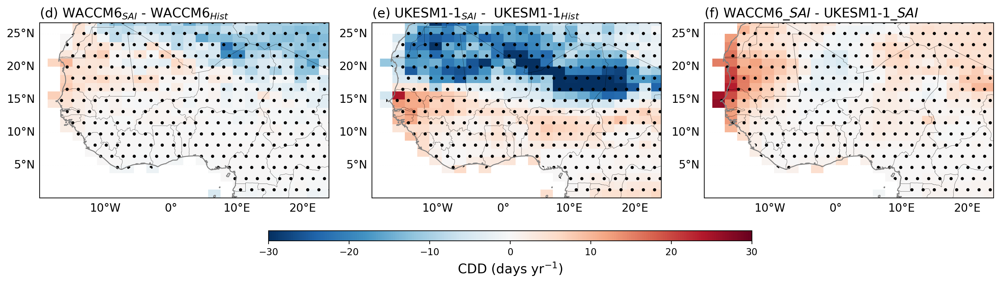

In [98]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.stats import ttest_1samp

# -----------------------------
# Compute historical mean
# -----------------------------
conc_waccm_hist_mean = xr.concat(waccm_cwd_hist, dim='members').mean('members').where(mask>0)
conc_ukesm_hist_mean = xr.concat(ukesm_cwd_hist, dim='members').mean('members').where(mask>0)

# -----------------------------
# Compute SAI ensembles
# -----------------------------
conc_waccm_sai = xr.concat(waccm_cwd, dim='members').where(mask>0)
conc_ukesm_sai = xr.concat(ukesm_cwd, dim='members').where(mask>0)

# -----------------------------
# Difference (SAI - Hist Mean)
# -----------------------------
diff_waccm = conc_waccm_sai - conc_waccm_hist_mean
diff_ukesm = conc_ukesm_sai - conc_ukesm_hist_mean
diff_models = conc_ukesm_sai - conc_waccm_sai

diff_waccm.load().where(mask>0)
diff_ukesm.load().where(mask>0)
diff_models.load().where(mask>0)
# -----------------------------
# Compute mean for plotting
# -----------------------------
data_list = [
    diff_waccm.mean('members'),
    diff_ukesm.mean('members'),
    diff_models.mean('members')
]

titles = [
    r"(d) WACCM6$_{SAI}$ - WACCM6$_{Hist}$",
    r"(e) UKESM1-1$_{SAI}$ -  UKESM1-1$_{Hist}$",
    r"(f) WACCM6_$SAI$ - UKESM1-1_$SAI$ "
]

cmaps = ["RdBu_r", "RdBu_r", "RdBu_r"]
vmin, vmax = -40, 40
dmax = 100
vlims = [(vmin, vmax), (vmin, vmax), (-dmax, dmax)]

# -----------------------------
# Significance function
# -----------------------------
def ttest_pval(da):
    return xr.apply_ufunc(
        lambda x: ttest_1samp(x, popmean=0, nan_policy='omit')[1],
        da,
        input_core_dims=[['members']],
        vectorize=True
    )

signif_waccm = ttest_pval(diff_waccm) < 0.05
signif_ukesm = ttest_pval(diff_ukesm) < 0.05
signif_models = ttest_pval(diff_models) < 0.05
signif_list = [signif_waccm, signif_ukesm, signif_models]

# -----------------------------
# Plotting
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': ccrs.PlateCarree()})
mappables = []

for da, signif, ax, title, cmap, (v0, v1) in zip(data_list, signif_list, axes, titles, cmaps, vlims):

    # Mean difference
    im = da.plot(ax=ax, cmap=cmap, vmin=v0, vmax=v1, add_colorbar=False, transform=ccrs.PlateCarree())
    
    # Overlay stippling using xarray-style contourf
    signif.where(mask>0).plot.contourf(
        ax=ax,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['.'],
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(title, loc='left', fontsize=14)
    ax.set_title('')
    mappables.append(im)
    cart_plot(ax, 0, ncols=3, nrows=1, llon=-20, rlon=24, blat=0, tlat=25)

# Shared colorbar
cax1 = fig.add_axes([0.27, 0.11, 0.48, 0.03])
cbar1 = fig.colorbar(mappables[0], cax=cax1, orientation='horizontal')
cbar1.set_label("CDD (days yr$^{-1}$)", fontsize=14)

plt.tight_layout()
plt.savefig('Images/CDD_sig_diffs_v2.png')

plt.show()


#### Hist - SAI

/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp/ipykernel_546/45963092.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


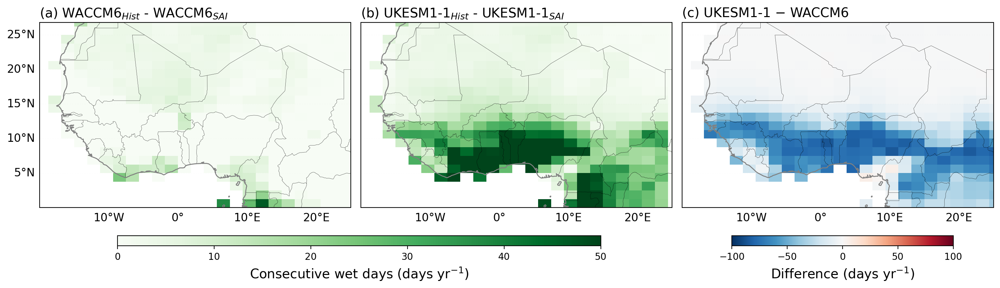

In [115]:
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import numpy as np

# --------------------------------------------------
# Organize data
# --------------------------------------------------
data_list = [
    conc_waccm_hist - conc_waccm,
    conc_ukesm_hist - conc_ukesm,
    conc_ukesm - conc_waccm
]

# --------------------------------------------------
# Student's t-test on difference (UKESM − WACCM)
# --------------------------------------------------
diff = conc_ukesm - conc_waccm



titles = [
    r"(a) WACCM6$_{Hist}$ - WACCM6$_{SAI}$",
    r"(b) UKESM1-1$_{Hist}$ - UKESM1-1$_{SAI}$",
    r"(c) UKESM1-1 − WACCM6"
]

cmaps = ["Greens", "Greens", "RdBu_r"]

# Color limits
vmin = 0 #min(conc_waccm.min(), conc_ukesm.min()).item()
vmax = 50#max(conc_waccm.max(), conc_ukesm.max()).item()

dmax = 100#np.nanmax(np.abs(data_list[2]))
vlims = [(vmin, vmax), (vmin, vmax), (-dmax, dmax)]

# --------------------------------------------------
# Figure
# --------------------------------------------------
fig, axes = plt.subplots(
    nrows=1, ncols=3,
    figsize=(15, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

mappables = []

# --------------------------------------------------
# Loop over panels
# --------------------------------------------------
for (ct,ax), da, title, cmap, (v0, v1) in zip(
    enumerate(axes), data_list, titles, cmaps, vlims
):
    im = da.plot(
        ax=ax,
        cmap=cmap,
        vmin=v0,
        vmax=v1,
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )

    # ax.coastlines()
    ax.set_title('')
    ax.set_title(title, loc='left', fontsize=14)
    mappables.append(im)
    cart_plot(ax,ct,ncols=3,nrows=1,llon=-20,rlon=25,blat=0,tlat=25)
# --------------------------------------------------
# Colorbars
# --------------------------------------------------
# --------------------------------------------------
# Shared colorbar for panels (a) and (b)
# --------------------------------------------------
cax1 = fig.add_axes([0.12, 0.11, 0.48, 0.03])  # [left, bottom, width, height]

cbar1 = fig.colorbar(
    mappables[0],
    cax=cax1,
    orientation="horizontal"
)
cbar1.set_label("Consecutive wet days (days yr$^{-1}$)", fontsize=14)


# --------------------------------------------------
# Difference colorbar for panel (c)
# --------------------------------------------------
cax2 = fig.add_axes([0.73, 0.11, 0.22, 0.03])

cbar2 = fig.colorbar(
    mappables[2],
    cax=cax2,
    orientation="horizontal"
)
cbar2.set_label("Difference (days yr$^{-1}$)", fontsize=14)


plt.tight_layout()
plt.savefig('Images/CWD_m2_diffs.png')
plt.show()


/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp/ipykernel_546/2046512768.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


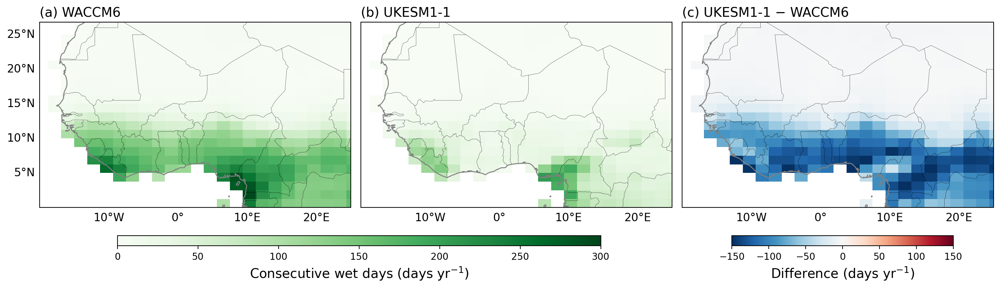

In [33]:
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import numpy as np

# --------------------------------------------------
# Organize data
# --------------------------------------------------
data_list = [
    conc_waccm,
    conc_ukesm,
    conc_ukesm - conc_waccm
]

# --------------------------------------------------
# Student's t-test on difference (UKESM − WACCM)
# --------------------------------------------------
diff = conc_ukesm - conc_waccm



titles = [
    "(a) WACCM6",
    "(b) UKESM1-1",
    "(c) UKESM1-1 − WACCM6"
]

cmaps = ["Greens", "Greens", "RdBu_r"]

# Color limits
vmin = 0 #min(conc_waccm.min(), conc_ukesm.min()).item()
vmax = 300#max(conc_waccm.max(), conc_ukesm.max()).item()

dmax = 150#np.nanmax(np.abs(data_list[2]))
vlims = [(vmin, vmax), (vmin, vmax), (-dmax, dmax)]

# --------------------------------------------------
# Figure
# --------------------------------------------------
fig, axes = plt.subplots(
    nrows=1, ncols=3,
    figsize=(15, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

mappables = []

# --------------------------------------------------
# Loop over panels
# --------------------------------------------------
for (ct,ax), da, title, cmap, (v0, v1) in zip(
    enumerate(axes), data_list, titles, cmaps, vlims
):
    im = da.plot(
        ax=ax,
        cmap=cmap,
        vmin=v0,
        vmax=v1,
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )

    # ax.coastlines()
    ax.set_title('')
    ax.set_title(title, loc='left', fontsize=14)
    mappables.append(im)
    cart_plot(ax,ct,ncols=3,nrows=1,llon=-20,rlon=25,blat=0,tlat=25)
# --------------------------------------------------
# Colorbars
# --------------------------------------------------
# --------------------------------------------------
# Shared colorbar for panels (a) and (b)
# --------------------------------------------------
cax1 = fig.add_axes([0.12, 0.11, 0.48, 0.03])  # [left, bottom, width, height]

cbar1 = fig.colorbar(
    mappables[0],
    cax=cax1,
    orientation="horizontal"
)
cbar1.set_label("Consecutive wet days (days yr$^{-1}$)", fontsize=14)


# --------------------------------------------------
# Difference colorbar for panel (c)
# --------------------------------------------------
cax2 = fig.add_axes([0.73, 0.11, 0.22, 0.03])

cbar2 = fig.colorbar(
    mappables[2],
    cax=cax2,
    orientation="horizontal"
)
cbar2.set_label("Difference (days yr$^{-1}$)", fontsize=14)


plt.tight_layout()
plt.savefig('Images/CWD_m2.png')
plt.show()


Consecutive wet days could mean,
1. if we count the number of days that continually had rain for a specific period without a break, that is 1 consecutive wet day,
2. if we count the number of days in a year that were consecutively wet and take the max -- This is what ETCCDI kinda says (We did this)

CWD. Maximum length of wet spell, maximum number of consecutive days with RR ≥ 1mm: Let RRij be the daily precipitation amount on day i in period j. Count the largest number of consecutive days where:

RRij ≥ 1mm

### R10mm

In [83]:
threshold = 10
n_cons_thresh = 1
waccm_cwd_hist = []
ukesm_cwd_hist = []
datasets = {'waccm':waccm_hist_,
            'ukesm':ukesm_hist_}

years = np.arange(1981,2014)

for dset in tqdm(datasets.keys()):
    
    for yy in years:
        ds__ = datasets[dset].sel(time=str(yy))
        out = xr.apply_ufunc(
            count_consecutive_threshold_chunks1,
            ds__ ,
            input_core_dims=[["time"]],
            output_core_dims=[[]],          # scalar output
            vectorize=True,
            dask="parallelized",
            output_dtypes=[np.int32],
            kwargs={
                "threshold": threshold,
                "n_cons_thresh": n_cons_thresh
            }
        )
        eval(f'{dset}_cwd_hist').append(out)

100%|██████████| 2/2 [00:00<00:00,  7.96it/s]


In [84]:
threshold = 10
n_cons_thresh = 1
waccm_cwd = []
ukesm_cwd = []
datasets = {'waccm':waccm_sai_,
            'ukesm':ukesm_sai_}

years = np.arange(2035,2085)

for dset in tqdm(datasets.keys()):
    
    for yy in years:
        ds__ = datasets[dset].sel(time=str(yy))
        out = xr.apply_ufunc(
            count_consecutive_threshold_chunks1,
            ds__ ,
            input_core_dims=[["time"]],
            output_core_dims=[[]],          # scalar output
            vectorize=True,
            dask="parallelized",
            output_dtypes=[np.int32],
            kwargs={
                "threshold": threshold,
                "n_cons_thresh": n_cons_thresh
            }
        )
        eval(f'{dset}_cwd').append(out)

100%|██████████| 2/2 [00:01<00:00,  1.23it/s]


/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp/ipykernel_546/1193300914.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


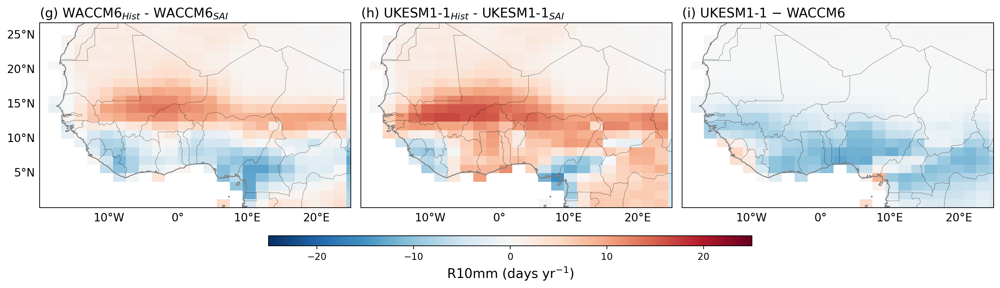

In [128]:
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import numpy as np

conc_waccm = xr.concat(waccm_cwd,dim='members').mean('members').where(mask>0)
conc_ukesm = xr.concat(ukesm_cwd,dim='members').mean('members').where(mask>0)

conc_waccm_hist = xr.concat(waccm_cwd_hist,dim='members').mean('members').where(mask>0)
conc_ukesm_hist = xr.concat(ukesm_cwd_hist,dim='members').mean('members').where(mask>0)

# --------------------------------------------------
# Organize data
# --------------------------------------------------
data_list = [
    conc_waccm_hist - conc_waccm,
    conc_ukesm_hist - conc_ukesm,
    conc_ukesm - conc_waccm
]

# --------------------------------------------------
# Student's t-test on difference (UKESM − WACCM)
# --------------------------------------------------
diff = conc_ukesm - conc_waccm



titles = [
    r"(g) WACCM6$_{Hist}$ - WACCM6$_{SAI}$",
    r"(h) UKESM1-1$_{Hist}$ - UKESM1-1$_{SAI}$",
    r"(i) UKESM1-1 − WACCM6"
]

cmaps = ["RdBu_r", "RdBu_r", "RdBu_r"]

# Color limits
vmin = -25 #min(conc_waccm.min(), conc_ukesm.min()).item()
vmax = 25#max(conc_waccm.max(), conc_ukesm.max()).item()

dmax = 25#np.nanmax(np.abs(data_list[2]))
vlims = [(vmin, vmax), (vmin, vmax), (-dmax, dmax)]

# --------------------------------------------------
# Figure
# --------------------------------------------------
fig, axes = plt.subplots(
    nrows=1, ncols=3,
    figsize=(15, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

mappables = []

# --------------------------------------------------
# Loop over panels
# --------------------------------------------------
for (ct,ax), da, title, cmap, (v0, v1) in zip(
    enumerate(axes), data_list, titles, cmaps, vlims
):
    im = da.plot(
        ax=ax,
        cmap=cmap,
        vmin=v0,
        vmax=v1,
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )

    # ax.coastlines()
    ax.set_title('')
    ax.set_title(title, loc='left', fontsize=14)
    mappables.append(im)
    cart_plot(ax,ct,ncols=3,nrows=1,llon=-20,rlon=25,blat=0,tlat=25)
# --------------------------------------------------
# Colorbars
# --------------------------------------------------
# --------------------------------------------------
# Shared colorbar for panels (a) and (b)
# --------------------------------------------------
cax1 = fig.add_axes([0.27, 0.11, 0.48, 0.03])  # [left, bottom, width, height]

cbar1 = fig.colorbar(
    mappables[0],
    cax=cax1,
    orientation="horizontal"
)
cbar1.set_label("R10mm (days yr$^{-1}$)", fontsize=14)


# --------------------------------------------------
# Difference colorbar for panel (c)
# --------------------------------------------------
# cax2 = fig.add_axes([0.73, 0.11, 0.22, 0.03])

# cbar2 = fig.colorbar(
#     mappables[2],
#     cax=cax2,
#     orientation="horizontal"
# )
# cbar2.set_label("Difference (days yr$^{-1}$)", fontsize=14)


plt.tight_layout()
# plt.savefig('Images/R10mm_diffs.png')
plt.show()


/tmp/ipykernel_148/4260677278.py:54: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  lambda x: ttest_1samp(x, popmean=0, nan_policy='omit')[1],
/srv/conda/envs/notebook/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will ha

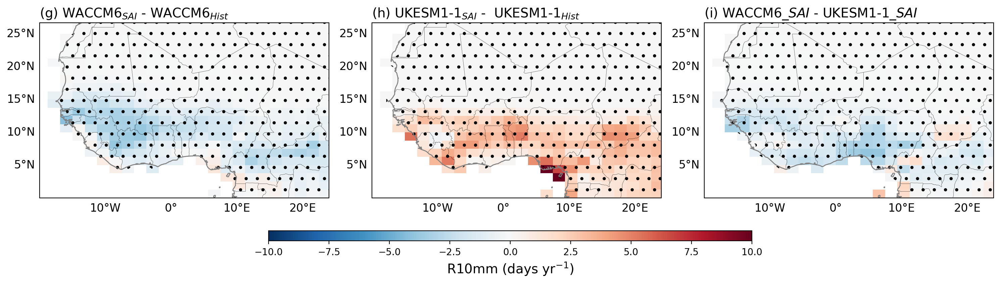

In [87]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.stats import ttest_1samp

# -----------------------------
# Compute historical mean
# -----------------------------
conc_waccm_hist_mean = xr.concat(waccm_cwd_hist, dim='members').mean('members').where(mask>0)
conc_ukesm_hist_mean = xr.concat(ukesm_cwd_hist, dim='members').mean('members').where(mask>0)

# -----------------------------
# Compute SAI ensembles
# -----------------------------
conc_waccm_sai = xr.concat(waccm_cwd, dim='members').where(mask>0)
conc_ukesm_sai = xr.concat(ukesm_cwd, dim='members').where(mask>0)

# -----------------------------
# Difference (SAI - Hist Mean)
# -----------------------------
diff_waccm = conc_waccm_sai - conc_waccm_hist_mean
diff_ukesm = conc_ukesm_sai - conc_ukesm_hist_mean
diff_models = conc_ukesm_sai - conc_waccm_sai

diff_waccm.load().where(mask>0)
diff_ukesm.load().where(mask>0)
diff_models.load().where(mask>0)
# -----------------------------
# Compute mean for plotting
# -----------------------------
data_list = [
    diff_waccm.mean('members'),
    diff_ukesm.mean('members'),
    diff_models.mean('members')
]

titles = [
    r"(g) WACCM6$_{SAI}$ - WACCM6$_{Hist}$",
    r"(h) UKESM1-1$_{SAI}$ -  UKESM1-1$_{Hist}$",
    r"(i) WACCM6_$SAI$ - UKESM1-1_$SAI$ "
]

cmaps = ["RdBu_r", "RdBu_r", "RdBu_r"]
vmin, vmax = -10, 10
dmax = 25
vlims = [(vmin, vmax), (vmin, vmax), (-dmax, dmax)]

# -----------------------------
# Significance function
# -----------------------------
def ttest_pval(da):
    return xr.apply_ufunc(
        lambda x: ttest_1samp(x, popmean=0, nan_policy='omit')[1],
        da,
        input_core_dims=[['members']],
        vectorize=True
    )

signif_waccm = ttest_pval(diff_waccm) < 0.05
signif_ukesm = ttest_pval(diff_ukesm) < 0.05
signif_models = ttest_pval(diff_models) < 0.05
signif_list = [signif_waccm, signif_ukesm, signif_models]

# -----------------------------
# Plotting
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': ccrs.PlateCarree()})
mappables = []

for da, signif, ax, title, cmap, (v0, v1) in zip(data_list, signif_list, axes, titles, cmaps, vlims):

    # Mean difference
    im = da.plot(ax=ax, cmap=cmap, vmin=v0, vmax=v1, add_colorbar=False, transform=ccrs.PlateCarree())
    
    # Overlay stippling using xarray-style contourf
    signif.where(mask>0).plot.contourf(
        ax=ax,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['.'],
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(title, loc='left', fontsize=14)
    ax.set_title('')
    mappables.append(im)
    cart_plot(ax, 0, ncols=3, nrows=1, llon=-20, rlon=24, blat=0, tlat=25)

# Shared colorbar
cax1 = fig.add_axes([0.27, 0.11, 0.48, 0.03])
cbar1 = fig.colorbar(mappables[0], cax=cax1, orientation='horizontal')
cbar1.set_label("R10mm (days yr$^{-1}$)", fontsize=14)

plt.tight_layout()
plt.savefig('Images/R10mm_sig_diffs_v2.png')

plt.show()


/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp/ipykernel_61/3025807117.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


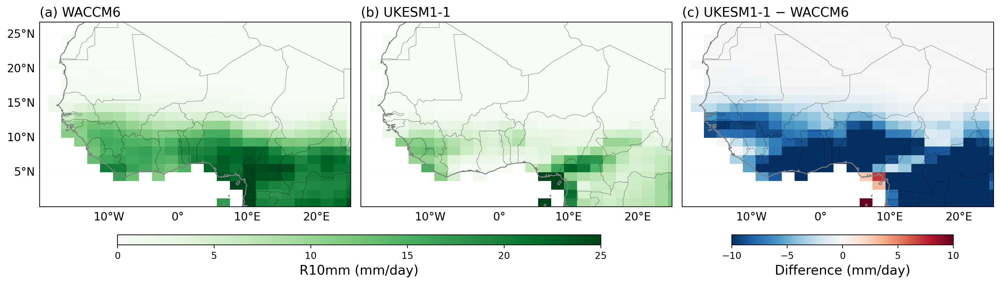

In [299]:
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import numpy as np

# --------------------------------------------------
# Organize data
# --------------------------------------------------
data_list = [
    conc_waccm,
    conc_ukesm,
    conc_ukesm - conc_waccm
]

# --------------------------------------------------
# Student's t-test on difference (UKESM − WACCM)
# --------------------------------------------------
diff = conc_ukesm - conc_waccm



titles = [
    "(a) WACCM6",
    "(b) UKESM1-1",
    "(c) UKESM1-1 − WACCM6"
]

cmaps = ["Greens", "Greens", "RdBu_r"]

# Color limits
vmin = 0 #min(conc_waccm.min(), conc_ukesm.min()).item()
vmax = 25#max(conc_waccm.max(), conc_ukesm.max()).item()

dmax = 10#np.nanmax(np.abs(data_list[2]))
vlims = [(vmin, vmax), (vmin, vmax), (-dmax, dmax)]

# --------------------------------------------------
# Figure
# --------------------------------------------------
fig, axes = plt.subplots(
    nrows=1, ncols=3,
    figsize=(15, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

mappables = []

# --------------------------------------------------
# Loop over panels
# --------------------------------------------------
for (ct,ax), da, title, cmap, (v0, v1) in zip(
    enumerate(axes), data_list, titles, cmaps, vlims
):
    im = da.plot(
        ax=ax,
        cmap=cmap,
        vmin=v0,
        vmax=v1,
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )

    # ax.coastlines()
    ax.set_title('')
    ax.set_title(title, loc='left', fontsize=14)
    mappables.append(im)
    cart_plot(ax,ct,ncols=3,nrows=1,llon=-20,rlon=25,blat=0,tlat=25)
# --------------------------------------------------
# Colorbars
# --------------------------------------------------
# --------------------------------------------------
# Shared colorbar for panels (a) and (b)
# --------------------------------------------------
cax1 = fig.add_axes([0.12, 0.11, 0.48, 0.03])  # [left, bottom, width, height]

cbar1 = fig.colorbar(
    mappables[0],
    cax=cax1,
    orientation="horizontal"
)
cbar1.set_label("R10mm (mm/day)", fontsize=14)


# --------------------------------------------------
# Difference colorbar for panel (c)
# --------------------------------------------------
cax2 = fig.add_axes([0.73, 0.11, 0.22, 0.03])

cbar2 = fig.colorbar(
    mappables[2],
    cax=cax2,
    orientation="horizontal"
)
cbar2.set_label("Difference (mm/day)", fontsize=14)


plt.tight_layout()
plt.savefig('Images/R10mm.png')
plt.show()


In [88]:
threshold = 20
n_cons_thresh = 1
waccm_cwd_hist = []
ukesm_cwd_hist = []
datasets = {'waccm':waccm_hist_,
            'ukesm':ukesm_hist_}

years = np.arange(1981,2014)

for dset in tqdm(datasets.keys()):
    
    for yy in years:
        ds__ = datasets[dset].sel(time=str(yy))
        out = xr.apply_ufunc(
            count_consecutive_threshold_chunks1,
            ds__ ,
            input_core_dims=[["time"]],
            output_core_dims=[[]],          # scalar output
            vectorize=True,
            dask="parallelized",
            output_dtypes=[np.int32],
            kwargs={
                "threshold": threshold,
                "n_cons_thresh": n_cons_thresh
            }
        )
        eval(f'{dset}_cwd_hist').append(out)

100%|██████████| 2/2 [00:00<00:00,  7.93it/s]


In [89]:
threshold = 20
n_cons_thresh = 1
waccm_cwd = []
ukesm_cwd = []
datasets = {'waccm':waccm_sai_,
            'ukesm':ukesm_sai_}

years = np.arange(2035,2085)

for dset in tqdm(datasets.keys()):
    
    for yy in years:
        ds__ = datasets[dset].sel(time=str(yy))
        out = xr.apply_ufunc(
            count_consecutive_threshold_chunks1,
            ds__ ,
            input_core_dims=[["time"]],
            output_core_dims=[[]],          # scalar output
            vectorize=True,
            dask="parallelized",
            output_dtypes=[np.int32],
            kwargs={
                "threshold": threshold,
                "n_cons_thresh": n_cons_thresh
            }
        )
        eval(f'{dset}_cwd').append(out)

100%|██████████| 2/2 [00:01<00:00,  1.98it/s]


In [90]:
conc_waccm = xr.concat(waccm_cwd,dim='members').mean('members').where(mask>0)
conc_ukesm = xr.concat(ukesm_cwd,dim='members').mean('members').where(mask>0)

conc_waccm_hist = xr.concat(waccm_cwd_hist,dim='members').mean('members').where(mask>0)
conc_ukesm_hist = xr.concat(ukesm_cwd_hist,dim='members').mean('members').where(mask>0)

/tmp/ipykernel_148/2499635666.py:54: SmallSampleWarning: After omitting NaNs, one or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  lambda x: ttest_1samp(x, popmean=0, nan_policy='omit')[1],
/srv/conda/envs/notebook/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will ha

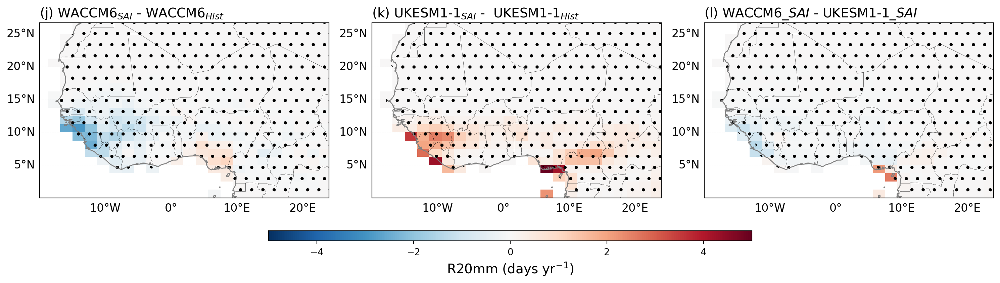

In [93]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from scipy.stats import ttest_1samp

# -----------------------------
# Compute historical mean
# -----------------------------
conc_waccm_hist_mean = xr.concat(waccm_cwd_hist, dim='members').mean('members').where(mask>0)
conc_ukesm_hist_mean = xr.concat(ukesm_cwd_hist, dim='members').mean('members').where(mask>0)

# -----------------------------
# Compute SAI ensembles
# -----------------------------
conc_waccm_sai = xr.concat(waccm_cwd, dim='members').where(mask>0)
conc_ukesm_sai = xr.concat(ukesm_cwd, dim='members').where(mask>0)

# -----------------------------
# Difference (SAI - Hist Mean)
# -----------------------------
diff_waccm = conc_waccm_sai - conc_waccm_hist_mean
diff_ukesm = conc_ukesm_sai - conc_ukesm_hist_mean
diff_models = conc_ukesm_sai - conc_waccm_sai

diff_waccm.load().where(mask>0)
diff_ukesm.load().where(mask>0)
diff_models.load().where(mask>0)
# -----------------------------
# Compute mean for plotting
# -----------------------------
data_list = [
    diff_waccm.mean('members'),
    diff_ukesm.mean('members'),
    diff_models.mean('members')
]

titles = [
    r"(j) WACCM6$_{SAI}$ - WACCM6$_{Hist}$",
    r"(k) UKESM1-1$_{SAI}$ -  UKESM1-1$_{Hist}$",
    r"(l) WACCM6_$SAI$ - UKESM1-1_$SAI$ "
]

cmaps = ["RdBu_r", "RdBu_r", "RdBu_r"]
vmin, vmax = -5, 5
dmax = 25
vlims = [(vmin, vmax), (vmin, vmax), (-dmax, dmax)]

# -----------------------------
# Significance function
# -----------------------------
def ttest_pval(da):
    return xr.apply_ufunc(
        lambda x: ttest_1samp(x, popmean=0, nan_policy='omit')[1],
        da,
        input_core_dims=[['members']],
        vectorize=True
    )

signif_waccm = ttest_pval(diff_waccm) < 0.05
signif_ukesm = ttest_pval(diff_ukesm) < 0.05
signif_models = ttest_pval(diff_models) < 0.05
signif_list = [signif_waccm, signif_ukesm, signif_models]

# -----------------------------
# Plotting
# -----------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5), subplot_kw={'projection': ccrs.PlateCarree()})
mappables = []

for da, signif, ax, title, cmap, (v0, v1) in zip(data_list, signif_list, axes, titles, cmaps, vlims):

    # Mean difference
    im = da.plot(ax=ax, cmap=cmap, vmin=v0, vmax=v1, add_colorbar=False, transform=ccrs.PlateCarree())
    
    # Overlay stippling using xarray-style contourf
    signif.where(mask>0).plot.contourf(
        ax=ax,
        levels=[0.5, 1.5],
        colors='none',
        hatches=['.'],
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )

    ax.set_title(title, loc='left', fontsize=14)
    ax.set_title('')
    mappables.append(im)
    cart_plot(ax, 0, ncols=3, nrows=1, llon=-20, rlon=24, blat=0, tlat=25)

# Shared colorbar
cax1 = fig.add_axes([0.27, 0.11, 0.48, 0.03])
cbar1 = fig.colorbar(mappables[0], cax=cax1, orientation='horizontal')
cbar1.set_label("R20mm (days yr$^{-1}$)", fontsize=14)

plt.tight_layout()
plt.savefig('Images/R20mm_sig_diffs_v2.png')

plt.show()


/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp/ipykernel_61/2228296904.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


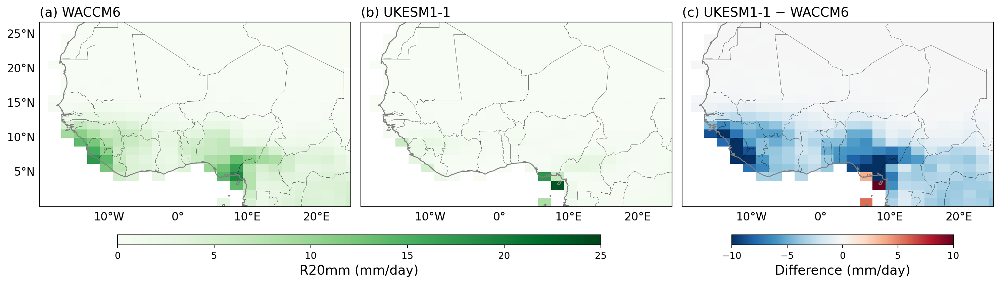

In [302]:
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import numpy as np

# --------------------------------------------------
# Organize data
# --------------------------------------------------
data_list = [
    conc_waccm,
    conc_ukesm,
    conc_ukesm - conc_waccm
]

# --------------------------------------------------
# Student's t-test on difference (UKESM − WACCM)
# --------------------------------------------------
diff = conc_ukesm - conc_waccm



titles = [
    "(a) WACCM6",
    "(b) UKESM1-1",
    "(c) UKESM1-1 − WACCM6"
]

cmaps = ["Greens", "Greens", "RdBu_r"]

# Color limits
vmin = 0 #min(conc_waccm.min(), conc_ukesm.min()).item()
vmax = 25#max(conc_waccm.max(), conc_ukesm.max()).item()

dmax = 10#np.nanmax(np.abs(data_list[2]))
vlims = [(vmin, vmax), (vmin, vmax), (-dmax, dmax)]

# --------------------------------------------------
# Figure
# --------------------------------------------------
fig, axes = plt.subplots(
    nrows=1, ncols=3,
    figsize=(15, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

mappables = []

# --------------------------------------------------
# Loop over panels
# --------------------------------------------------
for (ct,ax), da, title, cmap, (v0, v1) in zip(
    enumerate(axes), data_list, titles, cmaps, vlims
):
    im = da.plot(
        ax=ax,
        cmap=cmap,
        vmin=v0,
        vmax=v1,
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )

    # ax.coastlines()
    ax.set_title('')
    ax.set_title(title, loc='left', fontsize=14)
    mappables.append(im)
    cart_plot(ax,ct,ncols=3, nrows=1,llon=-20,rlon=25,blat=0,tlat=25)
# --------------------------------------------------
# Colorbars
# --------------------------------------------------
# --------------------------------------------------
# Shared colorbar for panels (a) and (b)
# --------------------------------------------------
cax1 = fig.add_axes([0.12, 0.11, 0.48, 0.03])  # [left, bottom, width, height]

cbar1 = fig.colorbar(
    mappables[0],
    cax=cax1,
    orientation="horizontal"
)
cbar1.set_label("R20mm (mm/day)", fontsize=14)


# --------------------------------------------------
# Difference colorbar for panel (c)
# --------------------------------------------------
cax2 = fig.add_axes([0.73, 0.11, 0.22, 0.03])

cbar2 = fig.colorbar(
    mappables[2],
    cax=cax2,
    orientation="horizontal"
)
cbar2.set_label("Difference (mm/day)", fontsize=14)


plt.tight_layout()
plt.savefig('Images/R20mm.png')
plt.show()


In [171]:
import xclim as xc

In [288]:
waccm_loaded_.attrs.update({
    "units": "mm/day",
    "long_name": "Daily precipitation",
    "description": "Total daily precipitation including rain and snow"
})

ukesm_loaded_.attrs.update({
    "units": "mm/day",
    "long_name": "Daily precipitation",
    "description": "Total daily precipitation including rain and snow"
})



### RX5D

In [289]:
waccm_rx5 = xc.indices.max_n_day_precipitation_amount(waccm_loaded_,window=5,freq='M')
ukesm_rx5 = xc.indices.max_n_day_precipitation_amount(ukesm_loaded_,window=5,freq='M')

<string>:7: FutureWarning: 'M' is deprecated and will be removed in a future version. Please use 'ME' instead of 'M'.
<string>:7: FutureWarning: 'M' is deprecated and will be removed in a future version. Please use 'ME' instead of 'M'.


/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp/ipykernel_61/3567297436.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


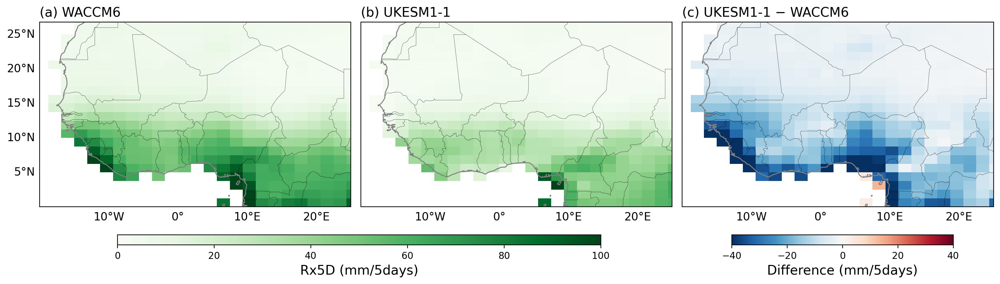

In [296]:
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import numpy as np

# --------------------------------------------------
# Organize data
# --------------------------------------------------
data_list = [
    waccm_rx5.mean('time'),
    ukesm_rx5.mean('time'),
    ukesm_rx5.mean('time') - waccm_rx5.mean('time')
]

# --------------------------------------------------
# Student's t-test on difference (UKESM − WACCM)
# --------------------------------------------------
diff = conc_ukesm - conc_waccm



titles = [
    "(a) WACCM6",
    "(b) UKESM1-1",
    "(c) UKESM1-1 − WACCM6"
]

cmaps = ["Greens", "Greens", "RdBu_r"]

# Color limits
vmin = 0 #min(conc_waccm.min(), conc_ukesm.min()).item()
vmax = 100#max(conc_waccm.max(), conc_ukesm.max()).item()

dmax = 40#np.nanmax(np.abs(data_list[2]))
vlims = [(vmin, vmax), (vmin, vmax), (-dmax, dmax)]

# --------------------------------------------------
# Figure
# --------------------------------------------------
fig, axes = plt.subplots(
    nrows=1, ncols=3,
    figsize=(15, 5),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

mappables = []

# --------------------------------------------------
# Loop over panels
# --------------------------------------------------
for (ct,ax), da, title, cmap, (v0, v1) in zip(
    enumerate(axes), data_list, titles, cmaps, vlims
):
    im = da.plot(
        ax=ax,
        cmap=cmap,
        vmin=v0,
        vmax=v1,
        add_colorbar=False,
        transform=ccrs.PlateCarree()
    )

    # ax.coastlines()
    ax.set_title('')
    ax.set_title(title, loc='left', fontsize=14)
    mappables.append(im)
    cart_plot(ax,ct,ncols=3, nrows=1,llon=-20,rlon=25,blat=0,tlat=25)
# --------------------------------------------------
# Colorbars
# --------------------------------------------------
# --------------------------------------------------
# Shared colorbar for panels (a) and (b)
# --------------------------------------------------
cax1 = fig.add_axes([0.12, 0.11, 0.48, 0.03])  # [left, bottom, width, height]

cbar1 = fig.colorbar(
    mappables[0],
    cax=cax1,
    orientation="horizontal"
)
cbar1.set_label("Rx5D (mm/5days)", fontsize=14)


# --------------------------------------------------
# Difference colorbar for panel (c)
# --------------------------------------------------
cax2 = fig.add_axes([0.73, 0.11, 0.22, 0.03])

cbar2 = fig.colorbar(
    mappables[2],
    cax=cax2,
    orientation="horizontal"
)
cbar2.set_label("Difference (mm/5days)", fontsize=14)


plt.tight_layout()
plt.savefig('Images/Rx5D.png')
plt.show()


Shade model agreement on panels a and b and statistical significance on panel c

In [278]:
__ii=xc.indices.(waccm_loaded_)

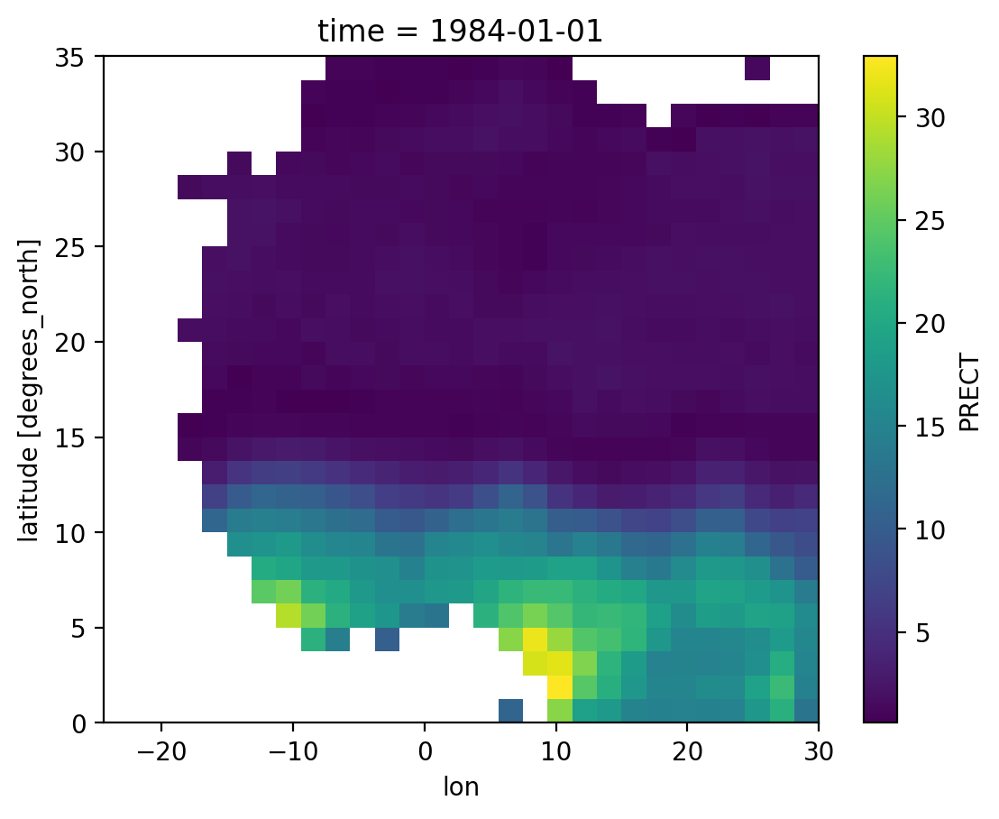

In [286]:
(__ii.mean('time')-conc_waccm).plot()

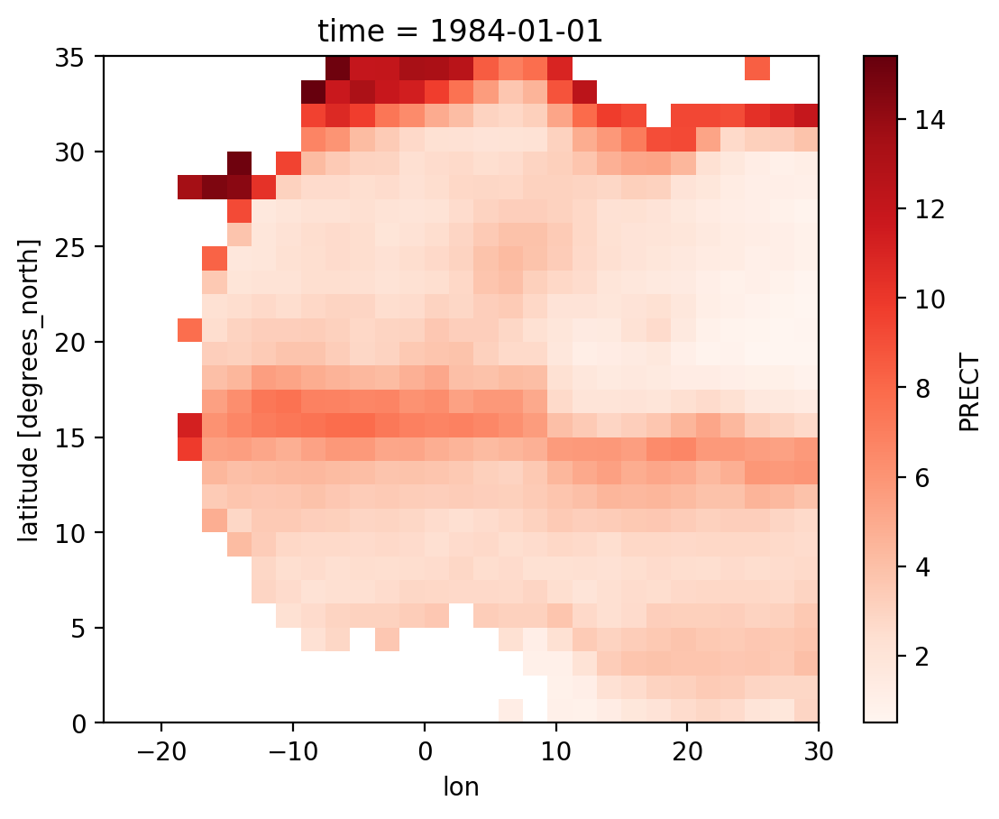

In [158]:
xr.concat(waccm_cwd,dim='members').mean('members').where(mask>0).plot(cmap="Reds")

In [109]:
waccm_loaded#.sortby('latitude')

<xarray.DataArray 'PRECT' (time: 16425, lat: 0, lon: 11)> Size: 0B
dask.array<where, shape=(16425, 0, 11), dtype=float32, chunksize=(16425, 0, 11), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 0B 
  * time     (time) object 131kB 2035-01-01 00:00:00 ... 2084-12-31 00:00:00
  * lon      (lon) float64 88B -22.5 -17.5 -12.5 -7.5 ... 12.5 17.5 22.5 27.5

## Dynamicus

### Check how much SAI JJAS months have deviated from Observation JJAS months
- Make difference plots between individual months and the climatology of the month from CHIRPS
- Do this for each model (WACCM and UKESM)
- The last column should be the difference between entire JJAS from model and JJAS from CHIRPS

In [2]:
## Load this helper function

def open_s3_xarray_ukesm(bucket, group, scenario, variable_name, partial_filename, anon=False):
    fs = s3fs.S3FileSystem(anon=anon)
    keys = fs.glob(f"{bucket}/{group}/{scenario}/{variable_name}_{partial_filename}*.nc")
    urls = [f"simplecache::s3://{k}" for k in keys][:2]
    print(f"{bucket}/{group}/{scenario}/{variable_name}_{partial_filename}*.nc")
    ds = xr.open_mfdataset(
        urls,
        engine="h5netcdf",
        combine="by_coords",
        parallel=True,
        backend_kwargs={
            "storage_options": {
                "s3": {"anon": anon},
                "simplecache": {"cache_storage": "/tmp/s3cache"},
            }
        },
    )
    lon_names = ['longitude', 'lon']
    lon_name = [ln for ln in lon_names if ln in ds][0]
    
    lat_names = ['latitude', 'lat']
    lat_name = [lt for lt in lat_names if lt in ds][0]
    print(lat_name)
    
    # ds = ds.assign_coords({lon_name:((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    ds = ds.assign_coords({lon_name: ((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    if lon_name != "lon":
        ds = ds.rename({lon_name: "lon", lat_name:"lat"})
    
    return ds#.load()


## Load this helper function

def open_s3_xarray_waccm(bucket, group, scenario, variable_name, partial_filename, anon=False):
    fs = s3fs.S3FileSystem(anon=anon)
    keys = fs.glob(f"{bucket}/{group}/{scenario}{variable_name}{partial_filename}.*.nc")
    urls = [f"simplecache::s3://{k}" for k in keys]
    urls.sort()
    print(urls)
    print(f"{bucket}/{group}/{scenario}{variable_name}{partial_filename}*.nc")
    ds = [xr.open_mfdataset(
        [url],
        engine="h5netcdf",
        combine="by_coords",
        parallel=True,
        backend_kwargs={
            "storage_options": {
                "s3": {"anon": anon},
                "simplecache": {"cache_storage": "/tmp/s3cache"},
            }
        },
    )[['PRECT']] for url in urls]

    print(ds[-1])
    ds[-1] = ds[-1].sel(time=slice("2080","2084"))
    
    ds = xr.concat(ds,dim='time')
    lon_names = ['longitude', 'lon']
    lon_name = [ln for ln in lon_names if ln in ds][0]
    
    lat_names = ['latitude', 'lat']
    lat_name = [lt for lt in lat_names if lt in ds][0]
    print(lat_name)
    
    # ds = ds.assign_coords({lon_name:((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    ds = ds.assign_coords({lon_name: ((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    if lon_name != "lon":
        ds = ds.rename({lon_name: "lon", lat_name:"lat"})
    
    return ds


def cart_plot(axes,ix, ncols=3,nrows=3, rlon=-150,llon=-60,tlat=42,blat=15):
    axes.add_feature(cf.BORDERS,linewidth=0.2) #add features (boarders )
    axes.add_feature(cf.COASTLINE,linewidth=1,color='gray') #coastlines 
    gl=axes.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.01, linestyle='--') #create the map type with grids 
    axes.set_extent([llon,rlon,blat,tlat]) #set the extent of the map
    if ix%ncols ==0:
        
        gl.top_labels = False; gl.left_labels = True #set which axis labels should show 
        gl.right_labels=False; gl.xlines = False; gl.bottom_labels=False

    elif ix>=(ncols*nrows)-ncols:
        gl.top_labels = False; gl.left_labels = False #set which axis labels should show 
        gl.right_labels=False; gl.xlines = False; gl.bottom_labels=True

    else:
        gl.top_labels = False; gl.left_labels = False #set which axis labels should show 
        gl.right_labels=False; gl.xlines = False; gl.bottom_labels=False
    if ix == (ncols*nrows)-ncols:
        gl.top_labels = False; gl.left_labels = True #set which axis labels should show 
        gl.right_labels=False; gl.xlines = False; gl.bottom_labels=True
    axes.xformatter = LONGITUDE_FORMATTER;  axes.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'color':'black','size':12} #change font style for x-axis 
    gl.ylabel_style = {'color':'black','size':12}#change font style for y-axis  

convert = lambda x: chr(ord('`')+(x+1)) if x<26 else chr(ord('`')+((x)//25))+chr(ord('`')+(x+1)%26)

In [80]:
# Connect to AWS S3 storage and load WACCM historical Precipitation 
fs = s3fs.S3FileSystem(anon=True)

# load catalogue
df = pd.read_csv("https://cmip6-pds.s3.amazonaws.com/pangeo-cmip6.csv")

# subset the archive
df_subset = df.query(
    "activity_id=='CMIP'& source_id=='CESM2-WACCM' & \
    experiment_id=='historical' & table_id=='day' & \
    variable_id=='pr'")

# get the path to a specific zarr store
zstore = df_subset.zstore.values[0]
zstore

's3://cmip6-pds/CMIP6/CMIP/NCAR/CESM2-WACCM/historical/r2i1p1f1/day/pr/gn/v20190415/'

In [81]:
lon_slice = slice(-25, 25)
lat_slice = slice(0,35)
time_slice = slice("1981","2014")

In [82]:
lon_name = 'lon'
lat_name = 'lat'
waccm_hist_pr = xr.open_dataset(
    zstore,
    engine="zarr",
    consolidated=True,
    chunks={},                        # or {} / None or 'auto' as you prefer
    storage_options={"anon": True}).assign_coords({lon_name: lambda ds: ((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name).sel({
    "time" : time_slice,
    lon_name : lon_slice, 
    lat_name : lat_slice}).load()* 24 * 60 * 60 

In [83]:
# Connect to AWS S3 storage and load UKESM historical Precipitation 
fs = s3fs.S3FileSystem(anon=True)

# load catalogue
df = pd.read_csv("https://cmip6-pds.s3.amazonaws.com/pangeo-cmip6.csv")

# subset the archive
df_subset = df.query(
    "activity_id=='CMIP'& source_id=='UKESM1-0-LL' & \
    experiment_id=='historical' & table_id=='day' & \
    variable_id=='pr'")

# get the path to a specific zarr store
zstore = df_subset.zstore.values[0]
zstore

's3://cmip6-pds/CMIP6/CMIP/MOHC/UKESM1-0-LL/historical/r1i1p1f2/day/pr/gn/v20190627/'

In [84]:
lon_name = 'lon'
lat_name = 'lat'
ukesm_hist_pr = xr.open_dataset(
    zstore,
    engine="zarr",
    consolidated=True,
    chunks={},                        # or {} / None or 'auto' as you prefer
    storage_options={"anon": True}).assign_coords({lon_name: lambda ds: ((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name).sel({
    "time" : time_slice,
    lon_name : lon_slice, 
    lat_name : lat_slice}).load() * 24 * 60 * 60

In [85]:
waccm_hist = waccm_hist_pr.sel(time=waccm_hist_pr.time.dt.month.isin([6,7,8,9]))
ukesm_hist = ukesm_hist_pr.sel(time=ukesm_hist_pr.time.dt.month.isin([6,7,8,9]))


In [3]:
sim_time = slice("2035","2085")
_lon_slice, _lat_slice = slice(-25,30), slice(0,35)

In [4]:
ukesm_e1 = open_s3_xarray_ukesm(
    bucket="reflective-persistent-prod-large",
    group="UKESM1-1",
    scenario="G6-1p5K-HiLLA/r12i1p1f2/apj/day/pr",
    variable_name="pr",
    partial_filename="day_UKESM1-1-LL_g6-1p5-hilla_r12i1p1f2_gn",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)

ukesm_e2 = open_s3_xarray_ukesm(
    bucket="reflective-persistent-prod-large",
    group="UKESM1-1",
    scenario="G6-1p5K-HiLLA/r2i1p1f2/apj/day/pr",
    variable_name="pr",
    partial_filename="day_UKESM1-1-LL_g6-1p5-hilla_r2i1p1f2_gn",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)

ukesm_e3 = open_s3_xarray_ukesm(
    bucket="reflective-persistent-prod-large",
    group="UKESM1-1",
    scenario="G6-1p5K-HiLLA/r3i1p1f2/apj/day/pr",
    variable_name="pr",
    partial_filename="day_UKESM1-1-LL_g6-1p5-hilla_r3i1p1f2_gn",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)

reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r12i1p1f2/apj/day/pr/pr_day_UKESM1-1-LL_g6-1p5-hilla_r12i1p1f2_gn*.nc
lat
reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r2i1p1f2/apj/day/pr/pr_day_UKESM1-1-LL_g6-1p5-hilla_r2i1p1f2_gn*.nc
lat
reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r3i1p1f2/apj/day/pr/pr_day_UKESM1-1-LL_g6-1p5-hilla_r3i1p1f2_gn*.nc
lat


In [5]:
## Compute ensemble avg for ensemble members
ukesm_ens = xr.concat([ukesm_e1['pr'],ukesm_e2['pr'],ukesm_e2['pr']], dim='ensembles')#.load()
ukesm_agv = (ukesm_e1['pr']+ukesm_e2['pr']+ukesm_e2['pr'])/3

In [6]:
ukesm_agv = ukesm_agv.to_dataset(name='pr')

In [7]:
sim_time = slice("2035","2084")
_lon_slice, _lat_slice = slice(-25,30), slice(0,35)

waccm_e1 = open_s3_xarray_waccm(
    bucket="reflective-persistent-prod-large",
    group="CESM2-WACCM",
    scenario="G6-1.5k-HiLLA/r1/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h1.",
    variable_name="PRECT",
    partial_filename="",
).sel( lon=_lon_slice, lat=_lat_slice)[['PRECT']]


waccm_e2 = open_s3_xarray_waccm(
    bucket="reflective-persistent-prod-large",
    group="CESM2-WACCM",
    scenario="G6-1.5k-HiLLA/r2/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.002.cam.h1.",
    variable_name="PRECT",
    partial_filename="",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)[['PRECT']]

waccm_e3 = open_s3_xarray_waccm(
    bucket="reflective-persistent-prod-large",
    group="CESM2-WACCM",
    scenario="G6-1.5k-HiLLA/r3/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.003.cam.h1.",
    variable_name="PRECT",
    partial_filename="",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)[['PRECT']]

# ukesm_e1 = open_s3_xarray(
#     bucket="reflective-persistent-prod-large",
#     group="UKESM1-1",
#     scenario="G6-1p5K-HiLLA/r2i1p1f2/apm/Amon/pr",
#     variable_name="pr",
#     partial_filename="Amon_UKESM1-1-LL_g6-1p5-hilla_r2i1p1f2_gn",
# ).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)

['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h1.PRECT.20350101-20391231.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h1.PRECT.20391231-20500105.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h1.PRECT.20500101-20600105.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h1.PRECT.20600101-20700105.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h1.PRECT.20700101-20800105.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/ADAY/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h1.PRECT.20800101-20841231.nc']
reflective-pers

In [8]:
def drop_duplicate_times(ds):
    _, unique_idx = np.unique(ds.time.values, return_index=True)
    return ds.isel(time=np.sort(unique_idx))

waccm_e1 = drop_duplicate_times(waccm_e1)
waccm_ens = xr.concat([waccm_e1['PRECT'],waccm_e2['PRECT'],waccm_e3['PRECT']],dim='ensembles')#.load()
waccm_agv = (waccm_e1['PRECT']+waccm_e2['PRECT']+waccm_e3['PRECT'])/3

In [9]:
_lon_slice, _lat_slice = slice(-25,30), slice(0,35)

mask = xr.open_mfdataset('africa_mask.nc')['rain'].assign_coords( longitude=(
            lambda ds: (ds.lon + 180) % 360 - 180)).sortby(
            lambda ds: ds['lon']).sel(lon=_lon_slice, lat=_lat_slice).interp_like(ukesm_agv)

In [10]:

mask

lons,lats = ukesm_agv.lon.values, ukesm_agv.lat.values

In [11]:
sel_months = [6,7,8,9]
chirps_hist_pr = xr.open_mfdataset(
    "CHIRPS_monthly/chirps_yearly_nc2/*.nc",
    preprocess=lambda ds: ds.sel(time=ds.time.dt.month.isin(sel_months))).sel(time=slice("2000","2024")).where(lambda da: da >= 0)['pr'].load()

### Check how much SAI JJAS months have deviated from Observation JJAS months
- Make difference plots between individual months and the climatology of the month from CHIRPS
- Do this for each model (WACCM and UKESM)
- The last column should be the difference between entire JJAS from model and JJAS from CHIRPS

In [82]:
chirps_mon = chirps_hist_pr.groupby('time.month').mean('time')
chirps_mon = chirps_mon.interp({'lon':lons,'lat':lats}).where(mask>0)

In [133]:
waccm_mask = (waccm_ens.mean('ensembles')*24*60*60*1000).resample(time='ME').sum('time').groupby('time.month').mean('time')
ukesm_mask = (ukesm_ens.mean('ensembles')*24*60*60).resample(time='ME').sum('time').groupby('time.month').mean('time')

In [134]:
waccm_mask_ = waccm_mask.interp({'lon':lons,'lat':lats}).where(mask>0)-chirps_mon#[5].plot()
ukesm_mask_ = ukesm_mask.interp({'lon':lons,'lat':lats}).where(mask>0)-chirps_mon

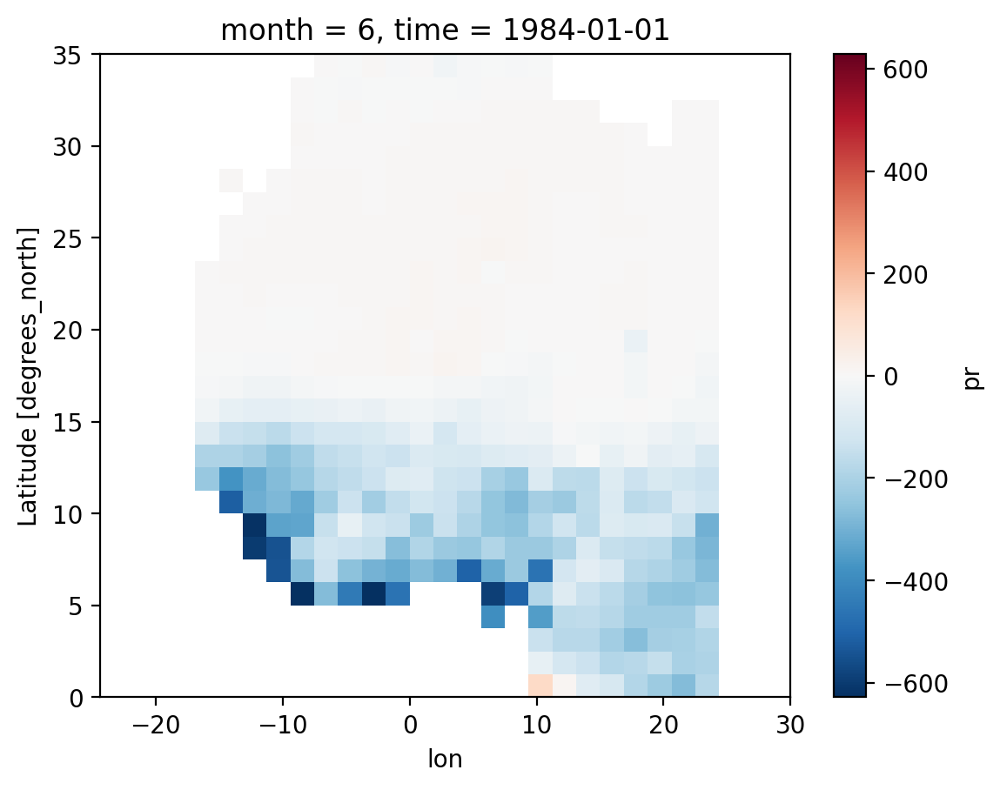

In [127]:
(ukesm_mask_-chirps_mon)[2][0].plot()

/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_ar

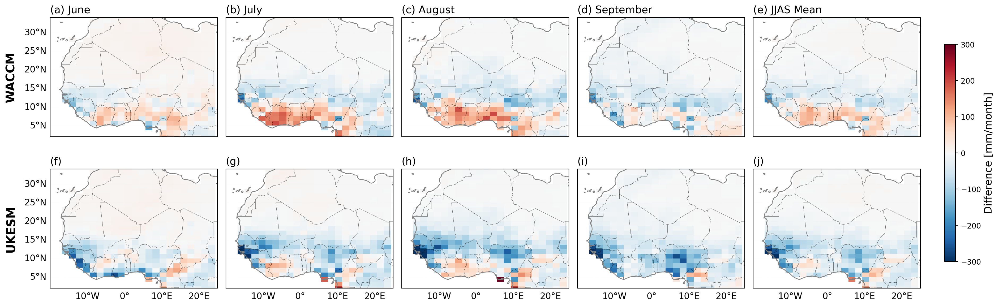

In [121]:
import string

# =========================
# Compute JJAS mean
# =========================
waccm_mean = waccm_mask_.mean(dim='month')
ukesm_mean = ukesm_mask_.mean(dim='month')

waccm_months = [waccm_mask_.isel(month=i) for i in range(4)]
ukesm_months = [ukesm_mask_.isel(month=i) for i in range(4)]

waccm_plots = waccm_months + [waccm_mean]
ukesm_plots = ukesm_months + [ukesm_mean]

month_labels = ['June', 'July', 'August', 'September', 'JJAS Mean']

# =========================
# Shared color scale
# =========================
combined = xr.concat([waccm_mask_, ukesm_mask_], dim='model')
vmin = combined.min().values
vmax = combined.max().values

# =========================
# Create figure
# =========================
fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(22, 9),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

letters = list(string.ascii_lowercase)  # a, b, c, ...
ct = 0

for row, dataset in enumerate([waccm_plots, ukesm_plots]):
    for col in range(5):

        ax = axes[row, col]

        im = dataset[col].plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            add_colorbar=False,
            vmin=-300,
            vmax=300,
            cmap='RdBu_r'
        )

        # Custom map styling
        cart_plot(ax, ct, ncols=5, nrows=2,
                  rlon=25, llon=-20, blat=2, tlat=32)

        # Column titles (top row only)
        # if row == 0:
        ax.set_title(f'({convert(ct)}) {month_labels[col]}',fontsize=14, loc='left') if row == 0 else ax.set_title(f'({convert(ct)})',fontsize=14, loc='left')

        ax.set_title('')
        # Row labels (left side)
        if col == 0:
            ax.text(
                -0.2, 0.5,
                ['WACCM', 'UKESM'][row],
                va='center',
                ha='right',
                rotation=90,
                transform=ax.transAxes,
                fontsize=16,
                fontweight='bold'
            )

        # Alphabetical panel labels
        # ax.text(
        #     0.02, 0.95,
        #     f'({letters[ct]})',
        #     transform=ax.transAxes,
        #     fontsize=13,
        #     fontweight='bold',
        #     va='top',
        #     ha='left'
        # )

        ct += 1

# =========================
# Vertical Colorbar
# =========================
cbar = fig.colorbar(
    im,
    ax=axes,
    orientation='vertical',
    fraction=0.012,
    pad=0.1
)

cbar.set_label('Difference [mm/month]', fontsize=14)

# Adjust spacing manually (better than tight_layout for cartopy)
plt.subplots_adjust(
    wspace=0.05,
    hspace=-0.3,
    right=0.87
)

plt.show()


/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_ar

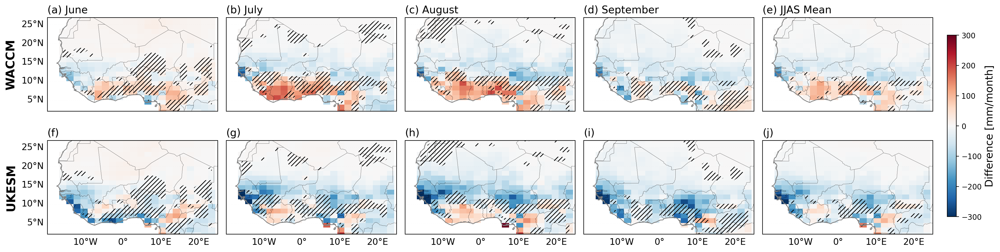

In [146]:
import string

# =========================================================
# 1. Compute JJAS mean for each model
# =========================================================
waccm_mean = waccm_mask_.mean(dim='month')
ukesm_mean = ukesm_mask_.mean(dim='month')

waccm_months = [waccm_mask_.isel(month=i) for i in range(4)]
ukesm_months = [ukesm_mask_.isel(month=i) for i in range(4)]

waccm_plots = waccm_months + [waccm_mean]
ukesm_plots = ukesm_months + [ukesm_mean]

diff_months = [waccm_mask_.isel(month=i) - ukesm_mask_.isel(month=i) for i in range(4)]
diff_mean = waccm_mean - ukesm_mean
diff_plots = diff_months + [diff_mean]

month_labels = ['June', 'July', 'August', 'September', 'JJAS Mean']

# =========================================================
# 2. Compute Model Agreement (WACCM vs UKESM sign)
# =========================================================
sign_waccm = xr.where(waccm_mask_ > 0, 1, -1)
sign_ukesm = xr.where(ukesm_mask_ > 0, 1, -1)

agreement = (sign_waccm * sign_ukesm) < 0

# Apply spatial mask where either model is missing
valid_mask = waccm_mask_.notnull() & ukesm_mask_.notnull()
agreement = agreement.where(valid_mask)

# JJAS mean agreement
agreement_jjas = agreement.mean(dim='month') > 0.5
agreement_months = [agreement.isel(month=i) for i in range(4)]
agreement_plots = agreement_months + [agreement_jjas]

# =========================================================
# 3. Create Figure
# =========================================================
fig, axes = plt.subplots(
    nrows=2,
    ncols=5,
    figsize=(22, 9),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

letters = list(string.ascii_lowercase)

ct= 0
# =========================================================
# 4. Plot Panels
# =========================================================
for row, model_plots in enumerate([waccm_plots, ukesm_plots]):
    for col in range(5):
        ax = axes[row, col]

        # Plot the model field
        im = model_plots[col].plot(
            ax=ax,
            transform=ccrs.PlateCarree(),
            add_colorbar=False,
            vmin=-300,
            vmax=300,
            cmap='RdBu_r'
        )

        # Add hatching where models agree
        agree = agreement_plots[col]

        ax.contourf(
            agree.lon,
            agree.lat,
            agree,
            levels=[0.5, 1],
            colors='none',
            hatches=['////'],
            transform=ccrs.PlateCarree()
        )

        # Custom map formatting
        cart_plot(ax, row*5+col, ncols=5, nrows=2,
                  rlon=25, llon=-20, blat=2, tlat=25)

        # Top row: month labels
        ax.set_title(f'({convert(ct)}) {month_labels[col]}',fontsize=14, loc='left') if row == 0 else ax.set_title(f'({convert(ct)})',fontsize=14, loc='left')

        ax.set_title('')

        # Row labels (model names)
        if col == 0:
            ax.text(
                -0.18, 0.5,
                ['WACCM', 'UKESM'][row],
                va='center',
                ha='right',
                rotation=90,
                transform=ax.transAxes,
                fontsize=16,
                fontweight='bold'
            )
        ct+=1
# =========================================================
# 5. Vertical Colorbar
# =========================================================
cbar = fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    orientation='vertical',
    fraction=0.01,
    pad=0.02
)
cbar.set_label('Difference [mm/month]', fontsize=14)

plt.subplots_adjust(wspace=0.05, hspace=-0.5, right=0.88)
plt.savefig('Images/model_disagreement_diff_from_chrips.png',dpi=300)
plt.show()


## Regional Changes in Precip per Year

In [20]:
## Load this helper function

def open_s3_xarray_ukesm(bucket, group, scenario, variable_name, partial_filename, anon=False):
    fs = s3fs.S3FileSystem(anon=anon)
    keys = fs.glob(f"{bucket}/{group}/{scenario}/{variable_name}_{partial_filename}*.nc")
    urls = [f"simplecache::s3://{k}" for k in keys][:2]
    print(f"{bucket}/{group}/{scenario}/{variable_name}_{partial_filename}*.nc")
    ds = xr.open_mfdataset(
        urls,
        engine="h5netcdf",
        combine="by_coords",
        parallel=True,
        backend_kwargs={
            "storage_options": {
                "s3": {"anon": anon},
                "simplecache": {"cache_storage": "/tmp/s3cache"},
            }
        },
    )
    lon_names = ['longitude', 'lon']
    lon_name = [ln for ln in lon_names if ln in ds][0]
    
    lat_names = ['latitude', 'lat']
    lat_name = [lt for lt in lat_names if lt in ds][0]
    print(lat_name)
    
    # ds = ds.assign_coords({lon_name:((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    ds = ds.assign_coords({lon_name: ((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    if lon_name != "lon":
        ds = ds.rename({lon_name: "lon", lat_name:"lat"})
    
    return ds


## Load this helper function

def open_s3_xarray_waccm(bucket, group, scenario, variable_name, partial_filename, anon=False):
    fs = s3fs.S3FileSystem(anon=anon)
    keys = fs.glob(f"{bucket}/{group}/{scenario}{variable_name}{partial_filename}*.nc")
    urls = [f"simplecache::s3://{k}" for k in keys]
    print(urls)
    print(f"{bucket}/{group}/{scenario}{variable_name}{partial_filename}*.nc")
    ds = xr.open_mfdataset(
        urls,
        engine="h5netcdf",
        combine="by_coords",
        parallel=True,
        backend_kwargs={
            "storage_options": {
                "s3": {"anon": anon},
                "simplecache": {"cache_storage": "/tmp/s3cache"},
            }
        },
    )
    lon_names = ['longitude', 'lon']
    lon_name = [ln for ln in lon_names if ln in ds][0]
    
    lat_names = ['latitude', 'lat']
    lat_name = [lt for lt in lat_names if lt in ds][0]
    print(lat_name)
    
    # ds = ds.assign_coords({lon_name:((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    ds = ds.assign_coords({lon_name: ((ds[lon_name] + 180) % 360 - 180)}).sortby(lon_name)
    if lon_name != "lon":
        ds = ds.rename({lon_name: "lon", lat_name:"lat"})
    
    return ds


def cart_plot(axes,ix, ncols=3,nrows=3, rlon=-150,llon=-60,tlat=42,blat=15):
    axes.add_feature(cf.BORDERS,linewidth=0.2) #add features (boarders )
    axes.add_feature(cf.COASTLINE,linewidth=1,color='gray') #coastlines 
    gl=axes.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color='gray', alpha=0.01, linestyle='--') #create the map type with grids 
    axes.set_extent([llon,rlon,blat,tlat]) #set the extent of the map
    if ix%ncols ==0:
        
        gl.top_labels = False; gl.left_labels = True #set which axis labels should show 
        gl.right_labels=False; gl.xlines = False; gl.bottom_labels=False

    elif ix>=(ncols*nrows)-ncols:
        gl.top_labels = False; gl.left_labels = False #set which axis labels should show 
        gl.right_labels=False; gl.xlines = False; gl.bottom_labels=True

    else:
        gl.top_labels = False; gl.left_labels = False #set which axis labels should show 
        gl.right_labels=False; gl.xlines = False; gl.bottom_labels=False
    if ix == (ncols*nrows)-ncols:
        gl.top_labels = False; gl.left_labels = True #set which axis labels should show 
        gl.right_labels=False; gl.xlines = False; gl.bottom_labels=True
    axes.xformatter = LONGITUDE_FORMATTER;  axes.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'color':'black','size':12} #change font style for x-axis 
    gl.ylabel_style = {'color':'black','size':12}#change font style for y-axis  

convert = lambda x: chr(ord('`')+(x+1)) if x<26 else chr(ord('`')+((x)//25))+chr(ord('`')+(x+1)%26)

In [21]:
sim_time = slice("2035","2085")
_lon_slice, _lat_slice = slice(-25,30), slice(0,35)

In [22]:
ukesm_e1 = open_s3_xarray_ukesm(
    bucket="reflective-persistent-prod-large",
    group="UKESM1-1",
    scenario="G6-1p5K-HiLLA/r12i1p1f2/apm/Amon/pr",
    variable_name="pr",
    partial_filename="Amon_UKESM1-1-LL_g6-1p5-hilla_r12i1p1f2_gn",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)

ukesm_e2 = open_s3_xarray_ukesm(
    bucket="reflective-persistent-prod-large",
    group="UKESM1-1",
    scenario="G6-1p5K-HiLLA/r2i1p1f2/apm/Amon/pr",
    variable_name="pr",
    partial_filename="Amon_UKESM1-1-LL_g6-1p5-hilla_r2i1p1f2_gn",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)

ukesm_e3 = open_s3_xarray_ukesm(
    bucket="reflective-persistent-prod-large",
    group="UKESM1-1",
    scenario="G6-1p5K-HiLLA/r3i1p1f2/apm/Amon/pr",
    variable_name="pr",
    partial_filename="Amon_UKESM1-1-LL_g6-1p5-hilla_r3i1p1f2_gn",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)

reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r12i1p1f2/apm/Amon/pr/pr_Amon_UKESM1-1-LL_g6-1p5-hilla_r12i1p1f2_gn*.nc
lat
reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r2i1p1f2/apm/Amon/pr/pr_Amon_UKESM1-1-LL_g6-1p5-hilla_r2i1p1f2_gn*.nc
lat
reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r3i1p1f2/apm/Amon/pr/pr_Amon_UKESM1-1-LL_g6-1p5-hilla_r3i1p1f2_gn*.nc
lat


In [23]:
## Compute ensemble avg for ensemble members
ukesm_agv = (ukesm_e1['pr']+ukesm_e2['pr']+ukesm_e2['pr'])/3

In [24]:
ukesm_agv = ukesm_agv.to_dataset(name='pr')

In [25]:
sim_time = slice("2035","2085")
_lon_slice, _lat_slice = slice(-25,30), slice(0,35)

waccm_e1 = open_s3_xarray_waccm(
    bucket="reflective-persistent-prod-large",
    group="CESM2-WACCM",
    scenario="G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.",
    variable_name="PRECT",
    partial_filename="",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)[['PRECT']]


waccm_e2 = open_s3_xarray_waccm(
    bucket="reflective-persistent-prod-large",
    group="CESM2-WACCM",
    scenario="G6-1.5k-HiLLA/r2/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.002.cam.h0.",
    variable_name="PRECT",
    partial_filename="",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)[['PRECT']]

waccm_e3 = open_s3_xarray_waccm(
    bucket="reflective-persistent-prod-large",
    group="CESM2-WACCM",
    scenario="G6-1.5k-HiLLA/r3/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.003.cam.h0.",
    variable_name="PRECT",
    partial_filename="",
).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)[['PRECT']]

# ukesm_e1 = open_s3_xarray(
#     bucket="reflective-persistent-prod-large",
#     group="UKESM1-1",
#     scenario="G6-1p5K-HiLLA/r2i1p1f2/apm/Amon/pr",
#     variable_name="pr",
#     partial_filename="Amon_UKESM1-1-LL_g6-1p5-hilla_r2i1p1f2_gn",
# ).sel(time=sim_time, lon=_lon_slice, lat=_lat_slice)

['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.PRECT.203501-203912.nc', 'simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.PRECT.204001-208412.nc']
reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.PRECT*.nc
lat
['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r2/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.002.cam.h0.PRECT.203501-208412.nc']
reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r2/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.002.cam.h0.PRECT*.nc
lat
['simplecache::s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r3/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.003.cam.h0.PRECT.203501-208412.nc']
reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r3/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5

In [26]:
waccm_agv = (waccm_e1['PRECT']+waccm_e2['PRECT']+waccm_e3['PRECT'])/3

In [27]:
waccm_agv=waccm_agv.to_dataset(name='pr')

In [28]:

sel_months = [6,7,8,9]  #JJAS
months = ukesm_agv['time'].dt.month
ukesm_wam = ukesm_agv.isel(time=months.isin(sel_months)) * 24 * 60 * 60* 31
lons,lats = ukesm_wam.lon.values, ukesm_wam.lat.values
times = [np.datetime64(t) for t in ukesm_wam.time.values]
ukesm_wam['time'] = times


months = waccm_agv['time'].dt.month
waccm_wam = waccm_agv.isel(time=months.isin(sel_months)) * 24 * 60 * 60* 31 *1000
waccm_wam['time'] = times
# waccm_wam = waccm_wam.interp({'lon':lons,'lat':lats})




/tmp/ipykernel_96/3774037649.py:6: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of time.
  ukesm_wam['time'] = times
/tmp/ipykernel_96/3774037649.py:6: UserWarning: Converting non-nanosecond precision datetime values to nanosecond precision. This behavior can eventually be relaxed in xarray, as it is an artifact from pandas which is now beginning to support non-nanosecond precision values. This warning is caused by passing non-nanosecond np.datetime64 or np.timedelta64 values to the DataArray or Variable constructor; it can be silenced by converting the values to nanosecond precision ahead of 

In [29]:
chirps_hist_pr = xr.open_mfdataset(
    "CHIRPS_monthly/chirps_yearly_nc2/*.nc",
    preprocess=lambda ds: ds.sel(time=ds.time.dt.month.isin(sel_months))).sel(time=slice("2000","2024")).where(lambda da: da >= 0)

chirps_wam = chirps_hist_pr.interp({'lon':lons,'lat':lats}).load()


In [53]:
chirps_wam = chirps_hist_pr.interp({'lon':lons,'lat':lats})['pr']

In [13]:
regions = {
    "Guinea Coast": {"lon": (-20, 10), "lat": (4, 8)},
    "Savannah":     {"lon": (-20, 10), "lat": (8, 12)},
    "Sahel":        {"lon": (-20, 10), "lat": (12, 18)},
}

In [32]:
def regional_yearly_mean(ds, var, region, ensemble_dim=None):
    da = ds[var].sel(
        lon=slice(region["lon"][0], region["lon"][1]),
        lat=slice(region["lat"][0], region["lat"][1])
    )
    # print(da)
    
    # average spatially
    da = da.reduce(np.nanmean, dim=['lat','lon'])
    
    # handle ensemble if present
    if ensemble_dim is not None and ensemble_dim in da.dims:
        da = da.reduce(np.nanmean, dim = ensemble_dim)
    
    # yearly mean
    da = da.groupby('time.year').mean('time')
    
    return da

In [54]:
results = {}
results_sai = {}
for name, reg in regions.items():
    
    ukesm = regional_yearly_mean(ukesm_wam, 'pr', reg, ensemble_dim='ensemble')
    waccm = regional_yearly_mean(waccm_wam, 'pr', reg, ensemble_dim='ensemble')
    
    chirps = chirps_hist_pr.sel(
        lon=slice(reg["lon"][0], reg["lon"][1]),
        lat=slice(reg["lat"][1], reg["lat"][0])
    ).reduce(np.nanmean, dim=['lat','lon']).groupby('time.year').mean('time')
    
    results[name] = {
        "UKESM": ukesm.load(),
        "WACCM": waccm.load(),
        "CHIRPS": chirps
    }

/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/geoaxes.py:394: UserWarning: The `map_projection` keyword argument is deprecated, use `projection` to instantiate a GeoAxes instead.
  warnings.warn("The `map_projection` keyword argument is "
/srv/conda/envs/notebook/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/tmp/ipykernel_96/3907139259.py:130: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


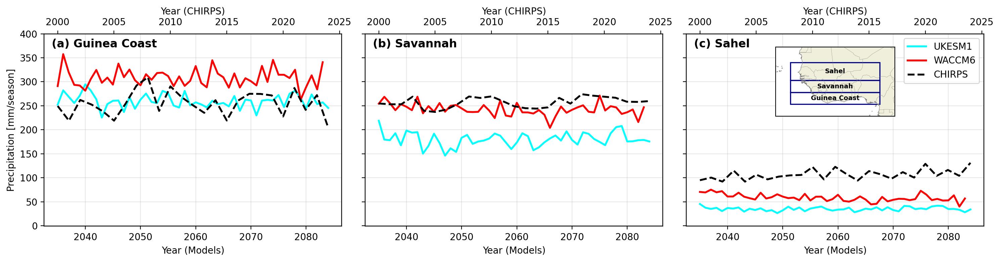

In [57]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15,4), sharey=True)

all_lines = []
all_labels = []

for (ix, ax), (region, data) in zip(enumerate(axes), results.items()):
    
    # -----------------------------
    # Bottom axis (models)
    # -----------------------------
    l1, = ax.plot(
        data["UKESM"].year,
        data["UKESM"],# * 24 * 60 * 60 * 31,
        label='UKESM1',
        linewidth=2,
        color='cyan'
    )
    
    l2, = ax.plot(
        data["WACCM"].year[:-1],
        data["WACCM"][:-1],# * 24 * 60 * 60 * 31 * 1000,
        label='WACCM6',
        linewidth=2,
        color='red'
    )
    
    ax.set_title(f'({convert(ix)}) {region}', loc='left',x=0.025, y=0.9, fontweight='bold')
    ax.set_xlabel("Year (Models)")
    ax.grid(alpha=0.3)

    ax.set_ylim(-1,400)
    # -----------------------------
    # Top axis (CHIRPS)
    # -----------------------------
    ax_top = ax.twiny()

    l3, = ax_top.plot(
        data["CHIRPS"].year,
        data["CHIRPS"]['pr'],
        label='CHIRPS',
        linewidth=2,
        color='black',
        linestyle='--'
    )

    # ax_top.set_xlim(ax.get_xlim())  # align x-axes

    # Only label top axis once (clean)
    # if ix == 1:
    ax_top.set_xlabel("Year (CHIRPS)")

    # Collect legend handles
    all_lines += [l1, l2, l3]
    all_labels += ['UKESM1', 'WACCM6', 'CHIRPS']

    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    import matplotlib.patches as patches
    from mpl_toolkits.axes_grid1.inset_locator import inset_axes
    from cartopy.mpl.geoaxes import GeoAxes

    # -----------------------------
    # Inset map on last panel
    # -----------------------------
    if ix == 2:
        
        ax_inset = inset_axes(
            ax,
            width="40%",
            height="40%",
            loc='upper center',
            borderpad=1,
            axes_class=GeoAxes,
            axes_kwargs=dict(map_projection=ccrs.PlateCarree()
                            , facecolor='white')
        )
        
        ax_inset.set_extent([-25, 15, 0, 22])
        ax_inset.coastlines(resolution='10m', linewidth=0.4,color='grey')
        ax_inset.add_feature(cfeature.BORDERS, linewidth=0.2,color='grey')
        ax_inset.add_feature(cfeature.LAND)
        # -----------------------------
        # Region definitions
        # -----------------------------
        regions_boxes = {
            "Guinea Coast": (-20, 4, 30, 4),
            "Savannah":     (-20, 8, 30, 4),
            "Sahel":        (-20, 12, 30, 6),
        }
    
        # -----------------------------
        # Draw rectangles + labels
        # -----------------------------
        for name, (lon, lat, width, height) in regions_boxes.items():
            
            rect = patches.Rectangle(
                (lon, lat),
                width,
                height,
                linewidth=1.2,
                edgecolor='navy',
                facecolor='none',
                transform=ccrs.PlateCarree()
            )
            ax_inset.add_patch(rect)
    
            ax_inset.text(
                lon + width/2,
                lat + height/2,
                name,
                fontsize=7,
                ha='center',
                va='center',
                transform=ccrs.PlateCarree(),
                weight='bold'
            )
# -----------------------------
# Labels
# -----------------------------
axes[0].set_ylabel("Precipitation [mm/season]")

# -----------------------------
# Legend (no duplicates)
# -----------------------------
unique = dict(zip(all_labels, all_lines))
axes[-1].legend(unique.values(), unique.keys(), loc='upper right')

plt.tight_layout()
plt.savefig('Images/precip_change_per_year_sai.png',dpi=250, bbox_inches="tight")
plt.show()